<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Air_Quality%2C_Weather%2C_and_Respiratory_Health_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('air_quality_health_dataset.csv')
df.head(11)

,date,region,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
0,2020-01-01,East,109.934283,31.382887,57.718373,47.654022,25.874070,0.956973,32.574682,37.555663,...,0,43.103376,75.706162,0,66.098466,9757,63.001573,11,1957.637287,42.348419
1,2020-01-02,Central,97.234714,47.094225,67.381383,50.734127,10.605095,0.990203,23.749138,24.900342,...,0,30.606591,69.652802,0,107.686174,9157,6.417798,13,2962.769470,27.712735
2,2020-01-03,East,112.953771,53.795917,61.158796,44.986899,18.361025,1.019288,35.530851,23.437165,...,0,13.037424,82.561183,1,77.445192,2058,66.001849,3,6912.007043,41.031516
3,2020-01-04,West,130.460597,88.315315,69.040084,20.575023,19.791700,1.284058,25.277106,22.388200,...,0,8.974779,73.642836,0,51.864000,8726,79.580923,6,9227.543628,40.543537
4,2020-01-05,South,95.316933,68.348297,75.716994,38.445776,20.079543,0.775835,35.996440,26.881835,...,1,96.022689,68.688106,0,148.714488,9720,6.301105,8,1277.810175,5.648920
5,2020-01-06,South,95.317261,39.967776,96.743090,28.442924,20.902480,0.746096,27.807108,26.932913,...,0,99.515344,67.393778,0,121.617654,4069,84.842058,9,6428.622693,47.149910
6,2020-01-07,West,131.584256,67.290544,73.576819,37.973942,23.052199,1.370986,16.231623,29.753139,...,0,89.792538,57.895350,0,123.546323,2500,12.335902,8,3831.189452,19.034779
7,2020-01-08,West,115.348695,36.790440,48.287486,49.800042,19.822963,0.861207,22.140670,20.369689,...,0,45.863143,76.470659,0,116.295865,8068,17.583370,13,3284.793439,41.342931
8,2020-01-09,North,90.610512,76.240366,102.801357,43.051508,18.159709,0.621089,26.556682,23.437526,...,0,80.791576,75.992329,0,64.373847,4705,83.640354,8,1882.424687,63.199856
9,2020-01-10,East,110.851201,52.933130,63.258197,51.480909,17.962053,0.854461,40.945512,35.152729,...,0,83.428220,79.538477,0,70.669442,8036,12.470203,11,8892.778335,17.498740


In [3]:
df.tail(11)

,date,region,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
2989,2020-03-10,North,148.233534,54.090200,71.101072,57.123047,18.413858,1.057409,34.501679,26.497060,...,0,94.395617,95.364991,0,116.140959,1534,91.032826,11,3845.337629,68.853422
2990,2020-03-11,South,130.327881,68.066523,112.021486,34.774791,26.755445,1.282669,19.660567,34.255770,...,0,90.142224,79.784106,0,88.231849,3407,85.298889,8,616.893421,57.944640
2991,2020-03-12,North,112.042366,64.595842,97.836812,25.488960,24.566955,1.307306,26.691194,27.621686,...,0,36.530480,77.768493,0,56.989829,3966,97.928012,7,2772.564532,25.417202
2992,2020-03-13,West,101.440737,45.025398,76.907006,35.938486,21.061498,0.871097,33.013735,30.571090,...,0,72.587551,88.787467,1,127.580809,1590,31.927573,9,8201.198439,43.946490
2993,2020-03-14,West,95.755821,67.781895,43.734131,30.530172,21.202904,1.094612,35.530100,27.009423,...,0,82.704367,50.823264,0,142.635561,7220,93.407154,10,2671.434830,41.152621
2994,2020-03-15,Central,80.961631,72.952924,79.613634,44.513475,18.480387,0.607367,23.974140,26.556968,...,0,81.248549,85.676950,1,102.743127,3816,17.951797,12,4182.438564,45.081707
2995,2020-03-16,West,101.549610,62.572040,82.032601,28.188065,15.451740,1.295485,26.473666,30.823665,...,0,6.268495,79.924698,0,63.894720,9727,17.517691,8,6376.519945,12.957398
2996,2020-03-17,Central,105.155051,77.289722,103.344355,39.271776,26.185755,0.765007,41.684453,28.343987,...,0,21.483037,76.189034,0,115.253298,7571,10.698859,7,2895.955761,46.956454
2997,2020-03-18,East,75.164788,41.738943,111.768944,48.380141,26.561040,1.235577,39.295269,26.050318,...,0,93.894493,60.866306,0,57.151724,1497,42.777210,10,8137.193349,18.919346
2998,2020-03-19,Central,106.683528,67.019256,66.300256,38.993041,15.579454,0.655209,31.667658,26.028273,...,0,73.990617,91.471722,0,66.552816,3412,1.218238,11,8997.326165,25.754999


In [5]:
df.shape

(3000, 26)

In [7]:
df.columns

Index(['date', 'region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'temperature', 'humidity', 'wind_speed', 'precipitation',
       'hospital_visits', 'emergency_visits', 'mobility_index',
       'school_closures', 'public_transport_usage', 'mask_usage_rate',
       'lockdown_status', 'industrial_activity', 'vehicle_count',
       'construction_activity', 'respiratory_admissions', 'population_density',
       'green_cover_percentage'],
      dtype='object')

In [8]:
df.dtypes

,0
date,object
region,object
AQI,float64
PM2.5,float64
PM10,float64
NO2,float64
SO2,float64
CO,float64
O3,float64
temperature,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   object 
 1   region                  3000 non-null   object 
 2   AQI                     3000 non-null   float64
 3   PM2.5                   3000 non-null   float64
 4   PM10                    3000 non-null   float64
 5   NO2                     3000 non-null   float64
 6   SO2                     3000 non-null   float64
 7   CO                      3000 non-null   float64
 8   O3                      3000 non-null   float64
 9   temperature             3000 non-null   float64
 10  humidity                3000 non-null   float64
 11  wind_speed              3000 non-null   float64
 12  precipitation           3000 non-null   float64
 13  hospital_visits         3000 non-null   int64  
 14  emergency_visits        3000 non-null   

In [10]:
df.describe(include = 'all')

,date,region,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
count,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
unique,730,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2020-03-01,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,100.640017,59.426348,80.062682,39.789545,20.173112,1.005489,29.970248,24.950278,...,0.092667,50.097325,75.081933,0.143667,100.544391,5453.904000,49.107961,9.923333,4981.290570,37.367668
std,NaN,NaN,19.736152,15.132393,20.522269,9.834362,5.011277,0.301906,8.026695,4.927167,...,0.290013,28.678922,14.375187,0.350810,29.058113,2564.332936,29.179745,3.161031,2821.503566,18.837611
min,NaN,NaN,35.174653,12.349443,3.266889,0.775997,3.352481,0.000000,0.000000,6.724567,...,0.000000,0.015119,50.006501,0.000000,50.044362,1005.000000,0.012882,1.000000,100.290565,5.011603
25%,NaN,NaN,87.449177,49.311574,66.028068,33.279636,16.761137,0.799757,24.590968,21.484840,...,0.000000,25.545471,62.458830,0.000000,74.893268,3256.500000,23.137463,8.000000,2549.128743,20.919710
50%,NaN,NaN,100.487296,59.665656,79.683829,39.771488,20.186704,1.008749,29.940792,24.947689,...,0.000000,49.583222,75.528614,0.000000,100.895015,5437.000000,49.107590,10.000000,4960.964843,37.615476
75%,NaN,NaN,113.471818,69.579966,94.064564,46.332485,23.524396,1.212121,35.551940,28.309660,...,0.000000,75.364285,87.375068,0.000000,126.249572,7629.000000,74.858781,12.000000,7408.607572,53.441531


In [11]:
df.isnull().sum()

,0
date,0
region,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0
temperature,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers

In [13]:
Q1 = df['hospital_visits'].quantile(0.25)
Q3 = df['hospital_visits'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['hospital_visits'] >= lower_bound) & (df['hospital_visits'] <= upper_bound)].copy()

print('Before removing outliers:', len(df))
print('After removing outliers:', len(df_outliers))

Before removing outliers: 3000
After removing outliers: 2987


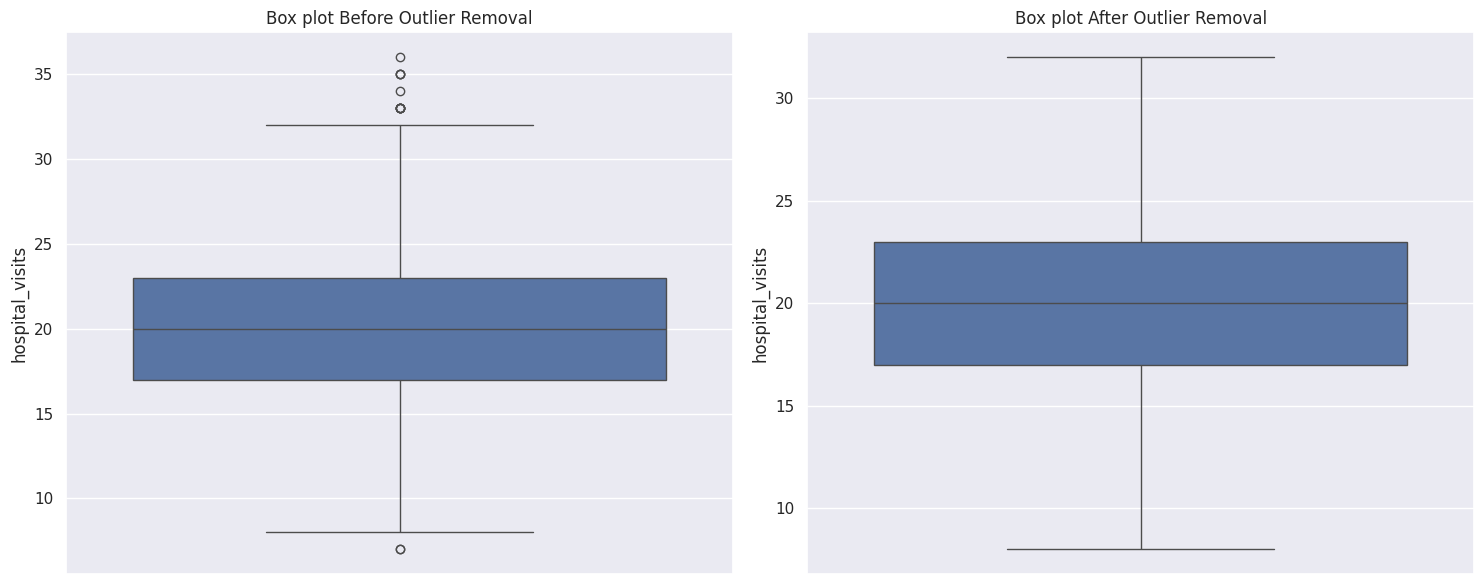

In [16]:
# Creating a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, y='hospital_visits', ax=axes[0])
axes[0].set_title('Box plot Before Outlier Removal')
axes[0].set_ylabel('hospital_visits')

sns.boxplot(data=df_outliers, y='hospital_visits', ax=axes[1])
axes[1].set_title('Box plot After Outlier Removal')
axes[1].set_ylabel('hospital_visits')
plt.tight_layout()
plt.show()

# Univariate Analysis

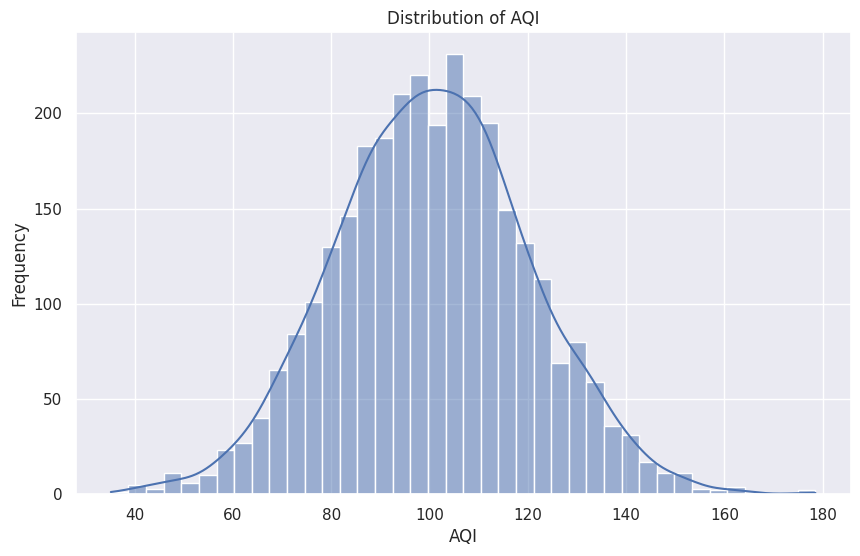

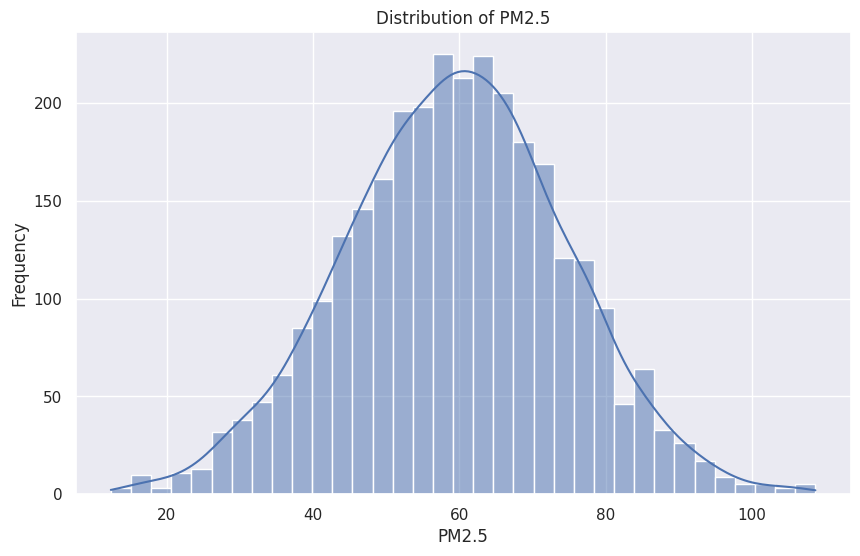

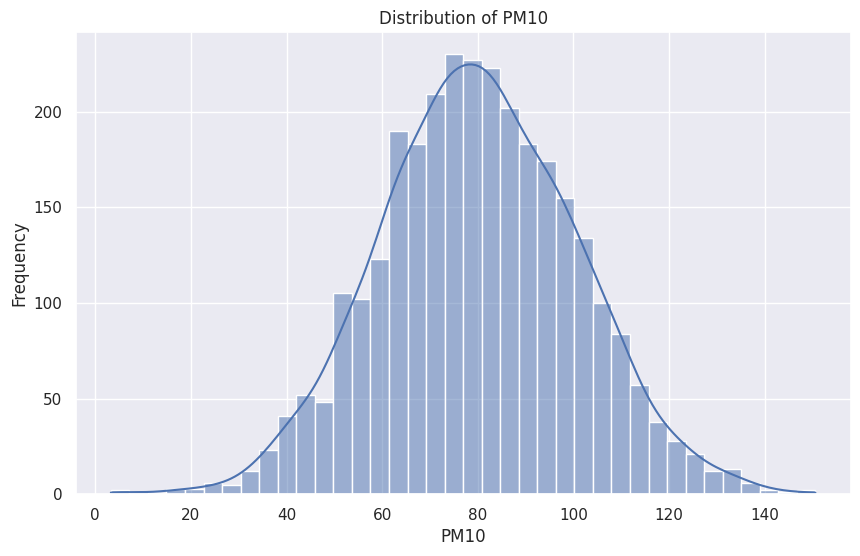

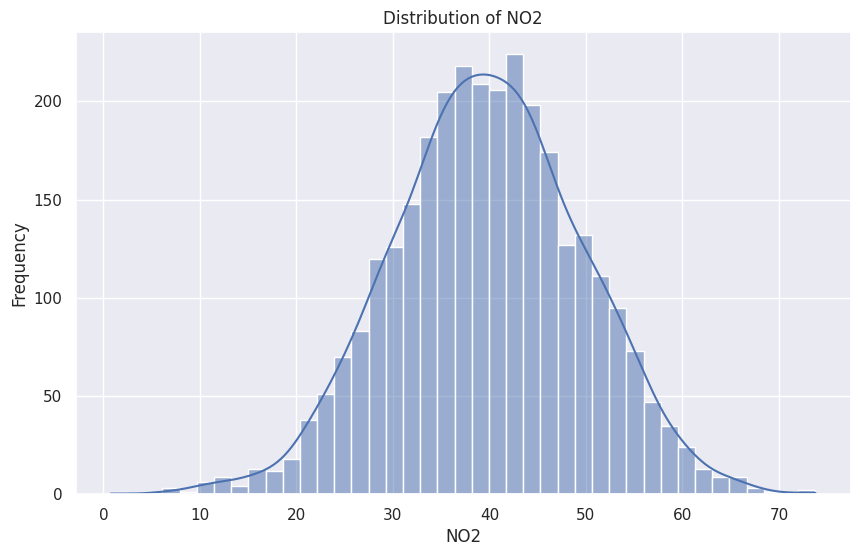

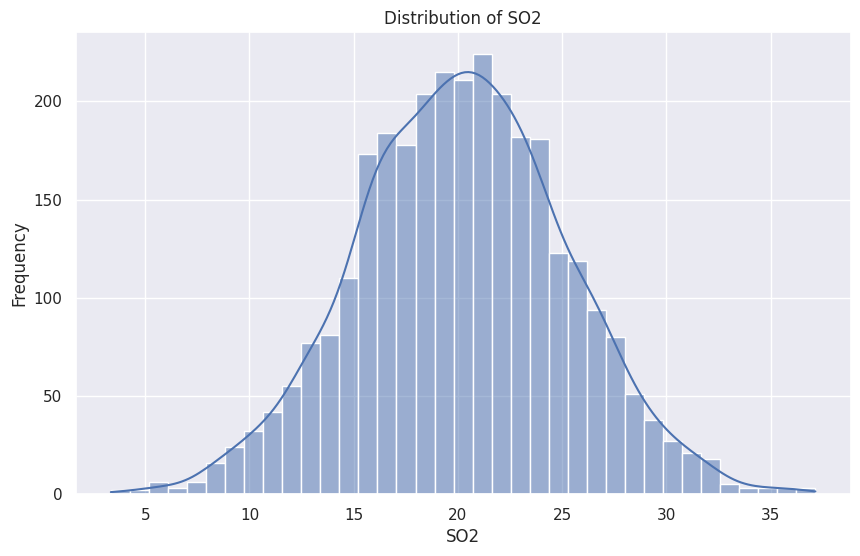

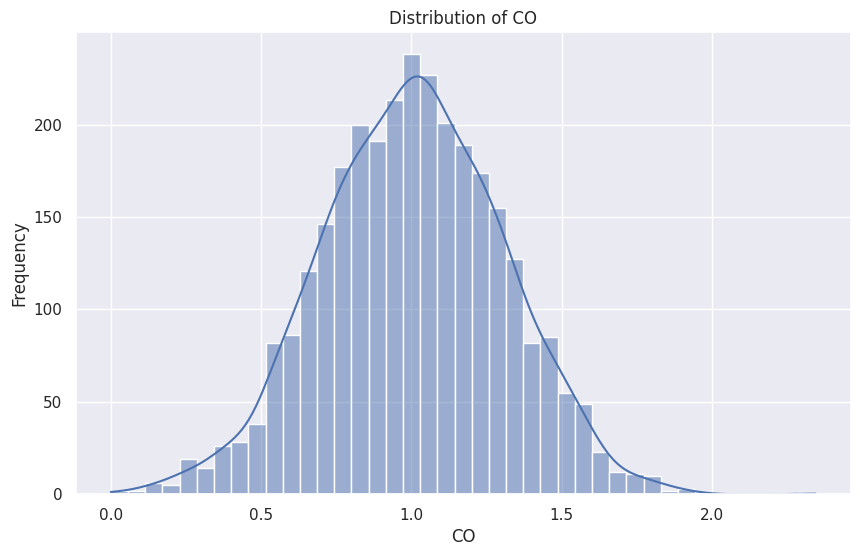

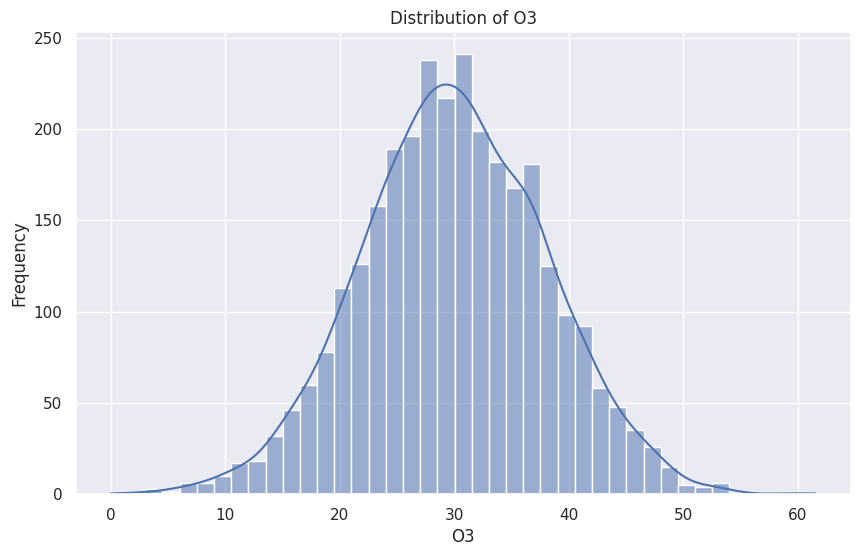

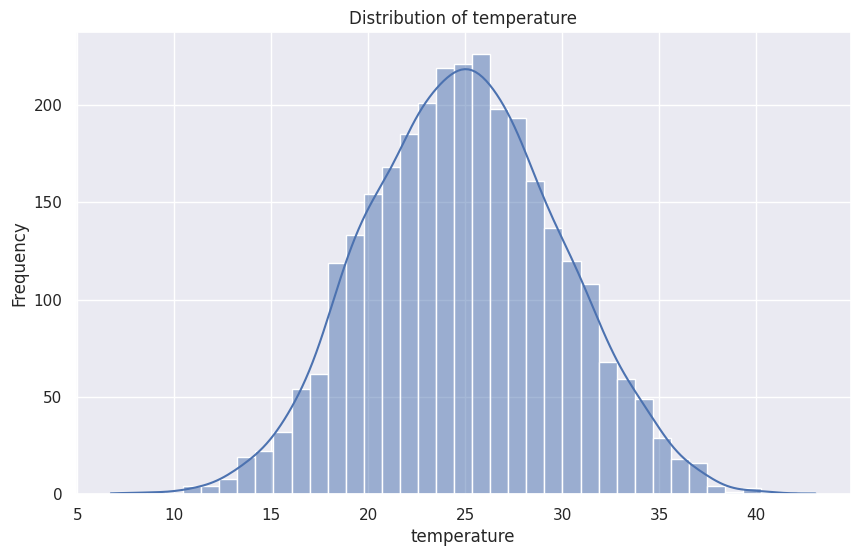

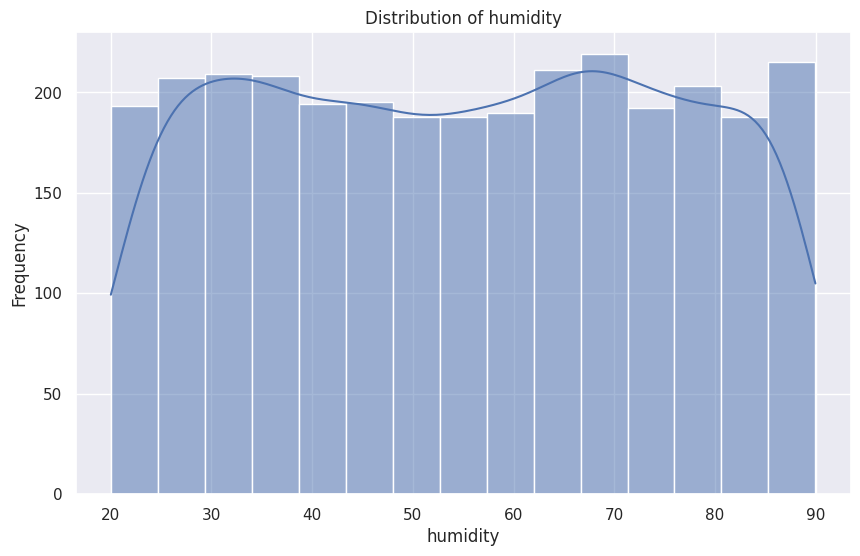

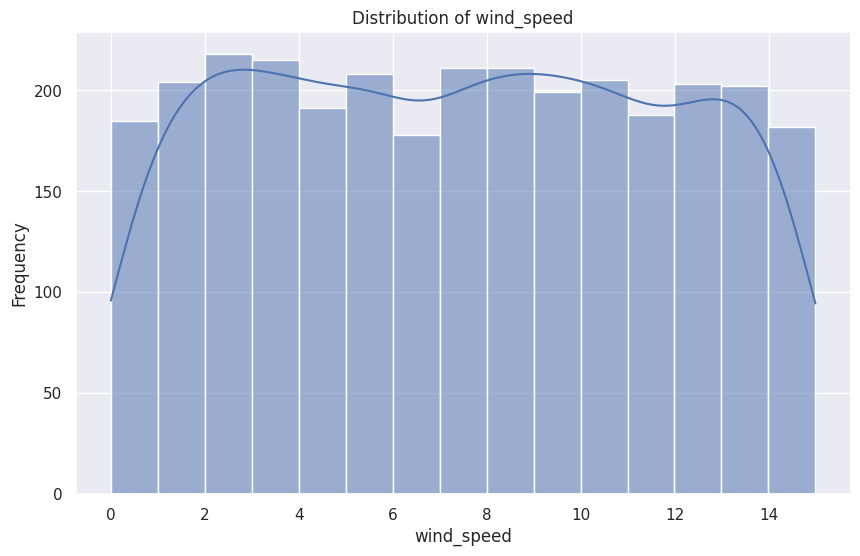

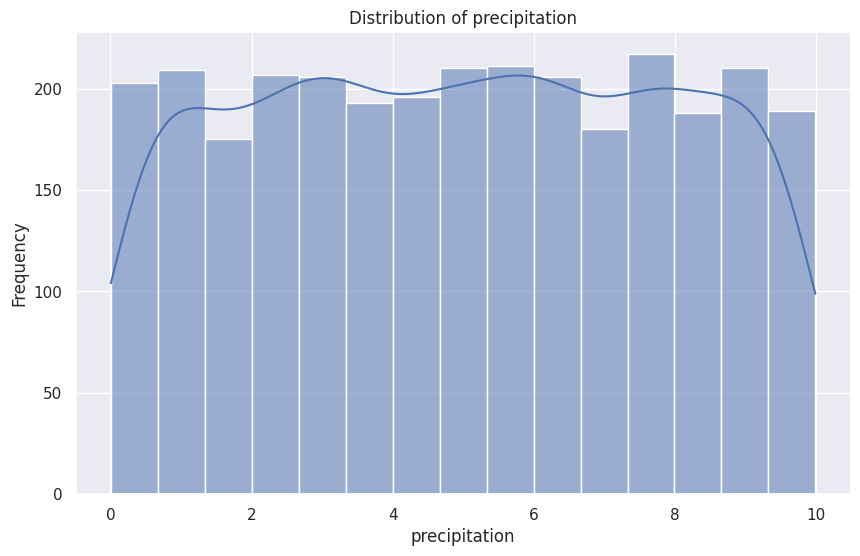

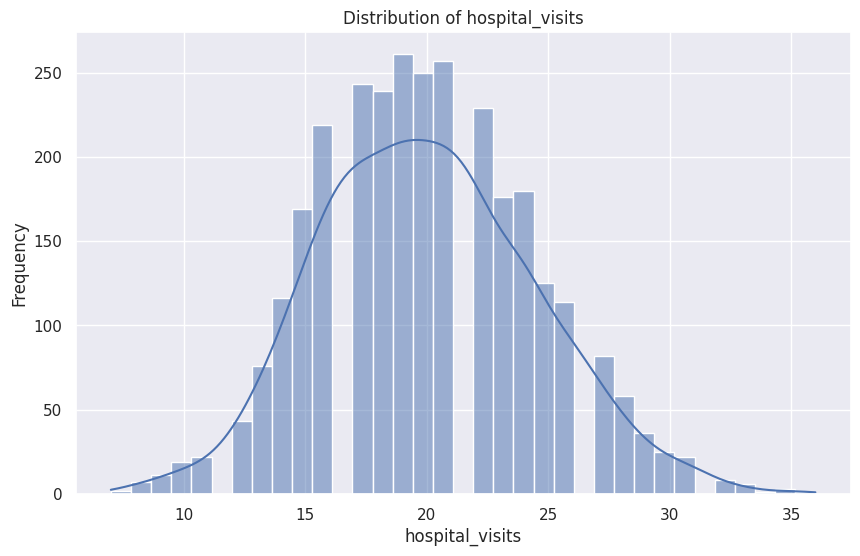

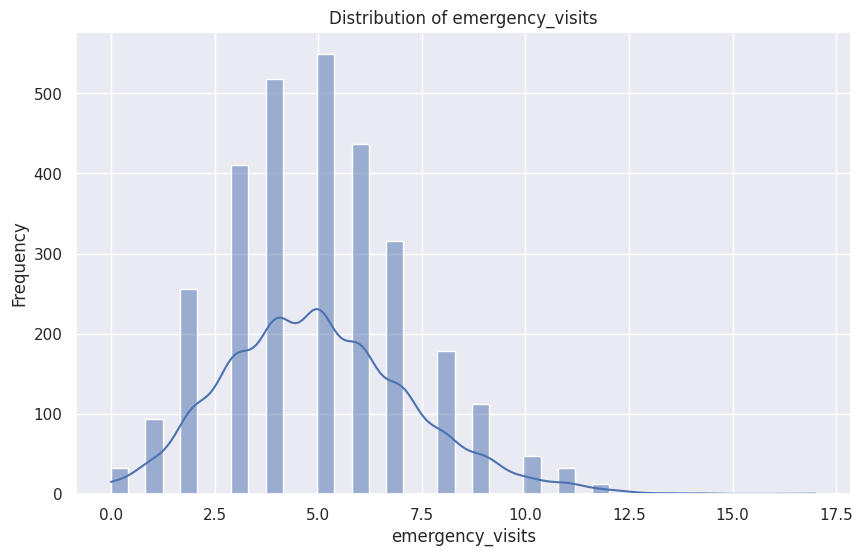

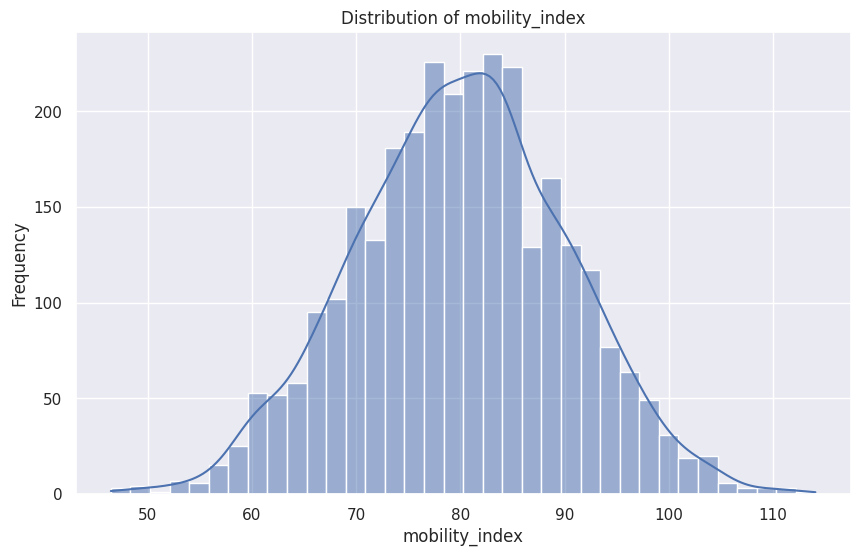

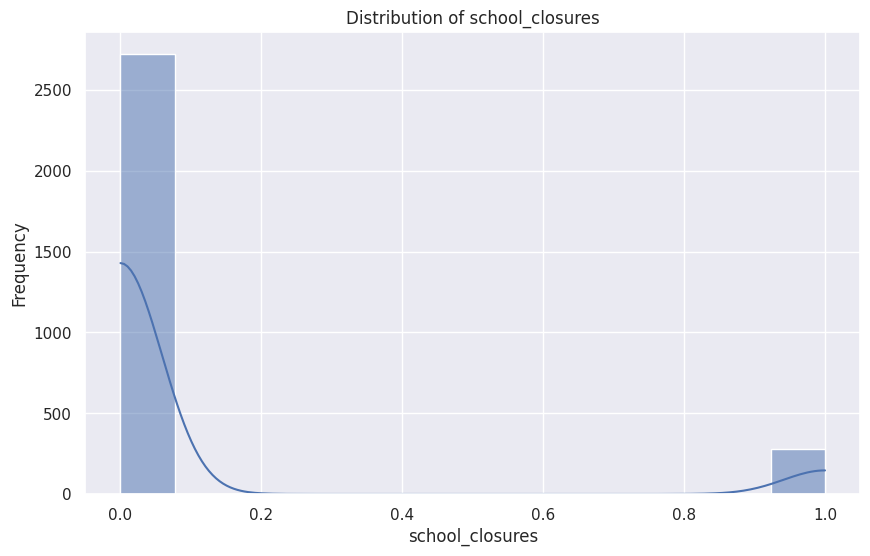

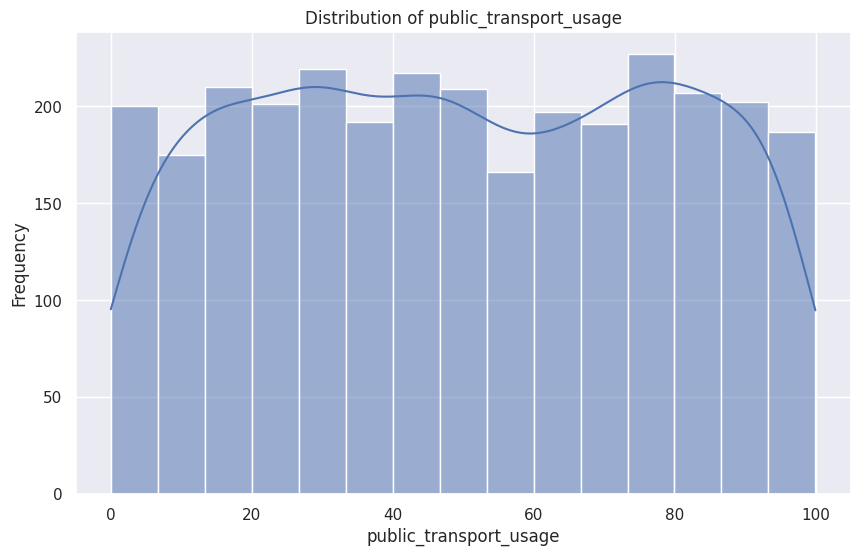

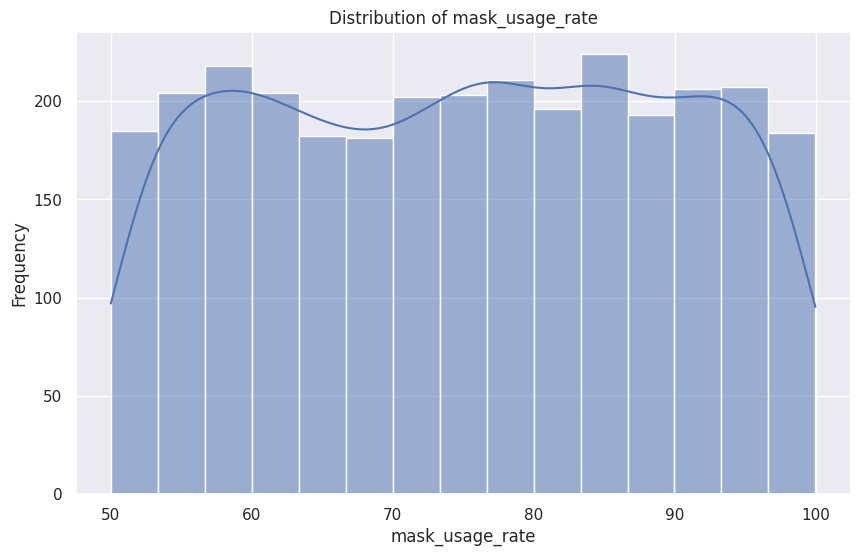

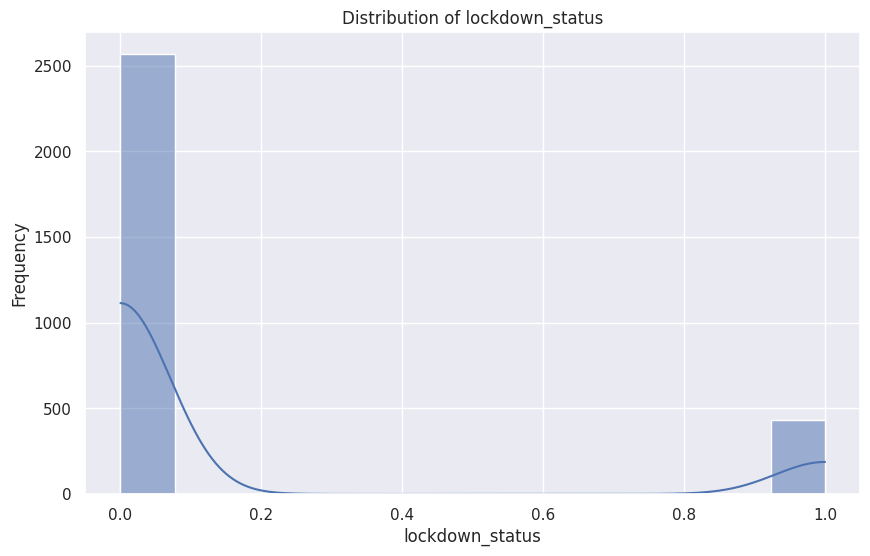

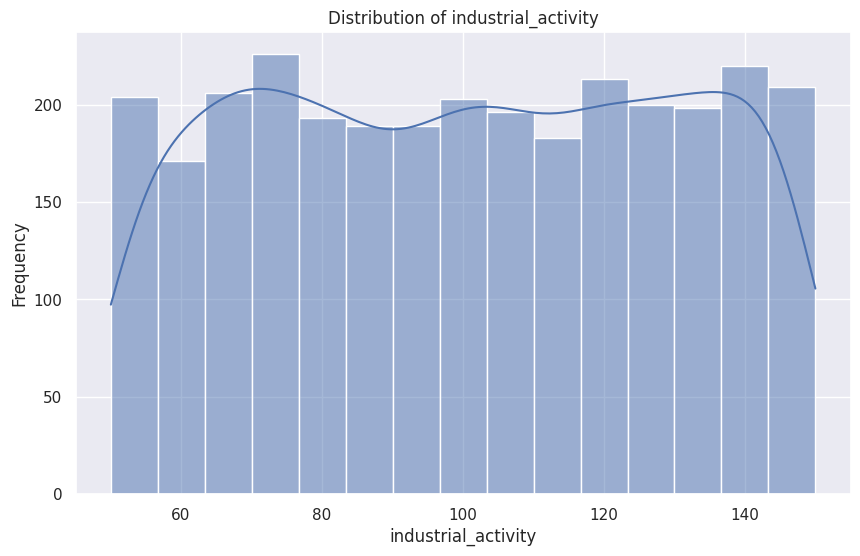

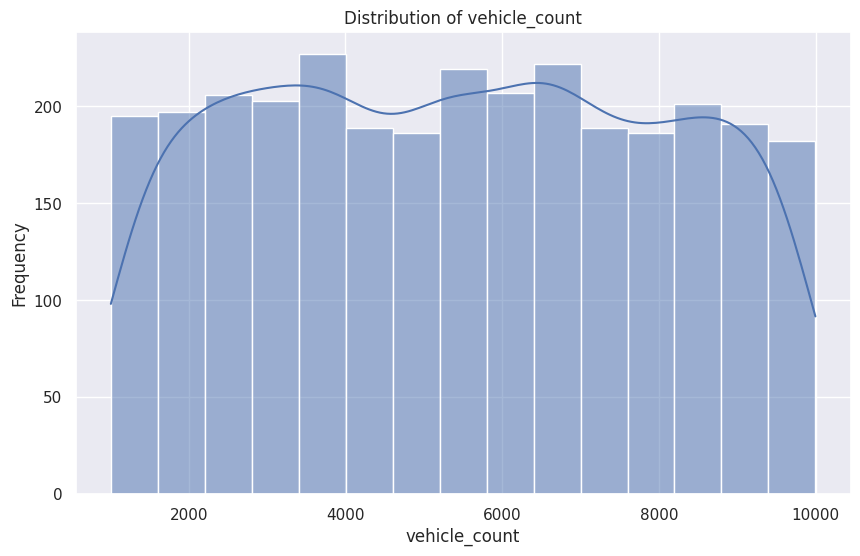

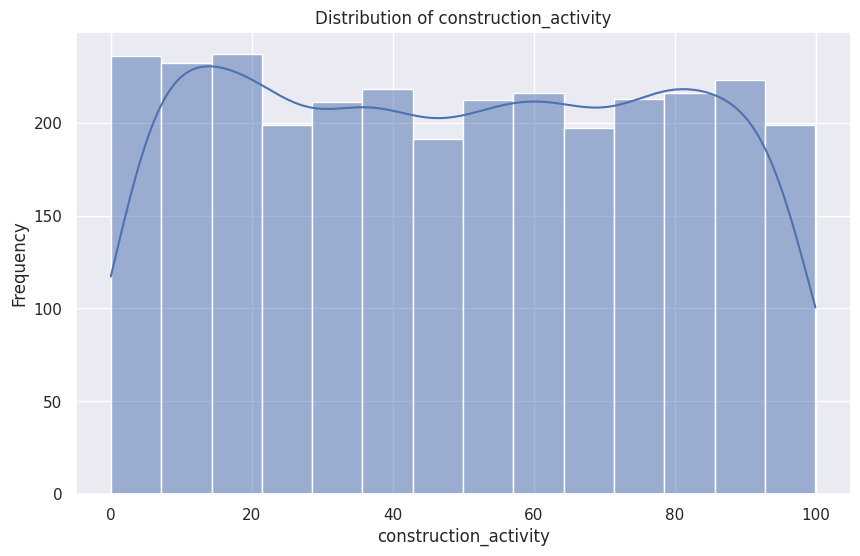

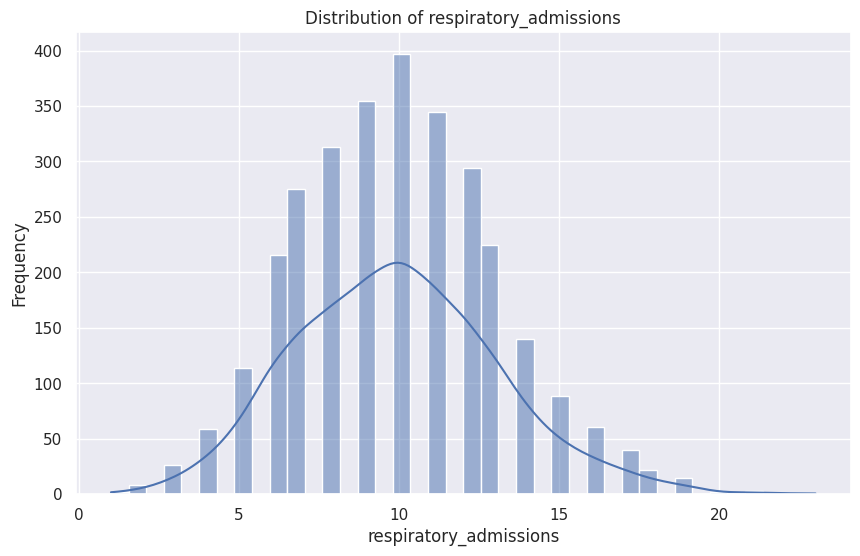

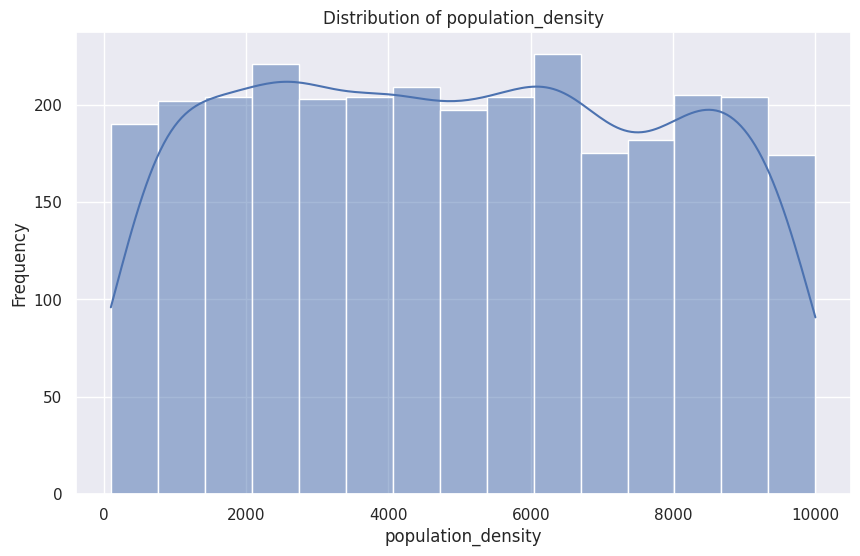

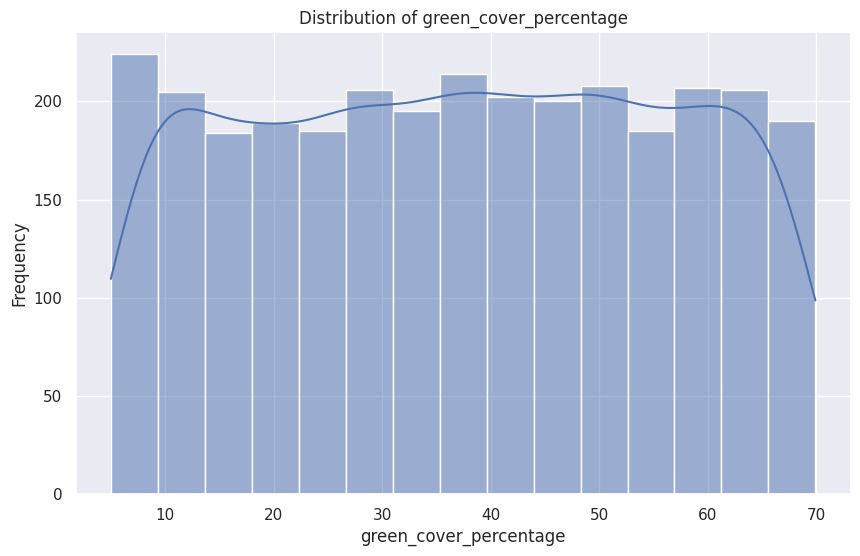

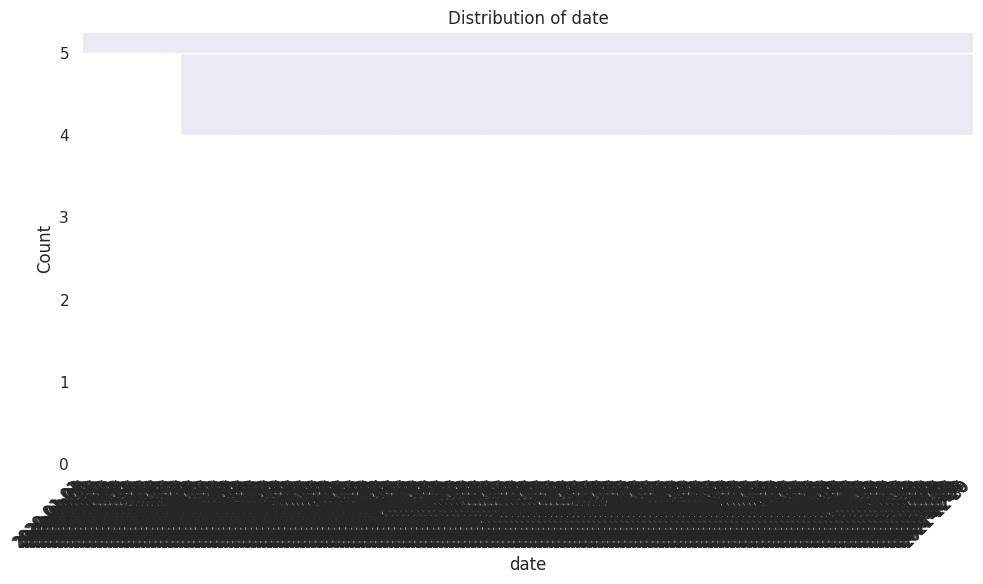

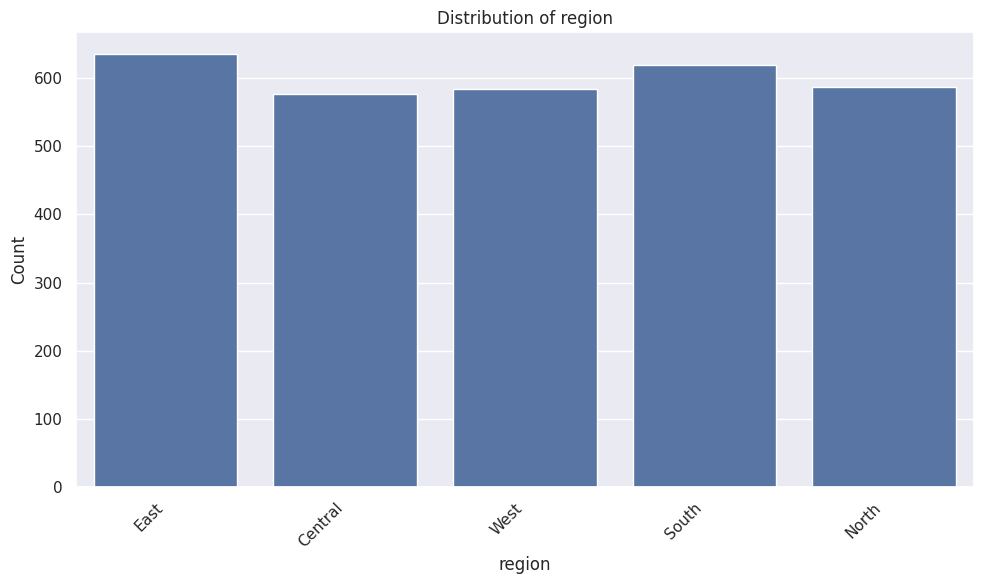

Value counts for date:
date
2020-03-01    5
2020-02-29    5
2020-02-28    5
2020-02-27    5
2020-02-26    5
             ..
2020-10-25    4
2020-10-26    4
2020-10-27    4
2020-10-28    4
2020-10-18    4
Name: count, Length: 730, dtype: int64

Value counts for region:
region
East       635
South      619
North      586
West       583
Central    577
Name: count, dtype: int64



In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

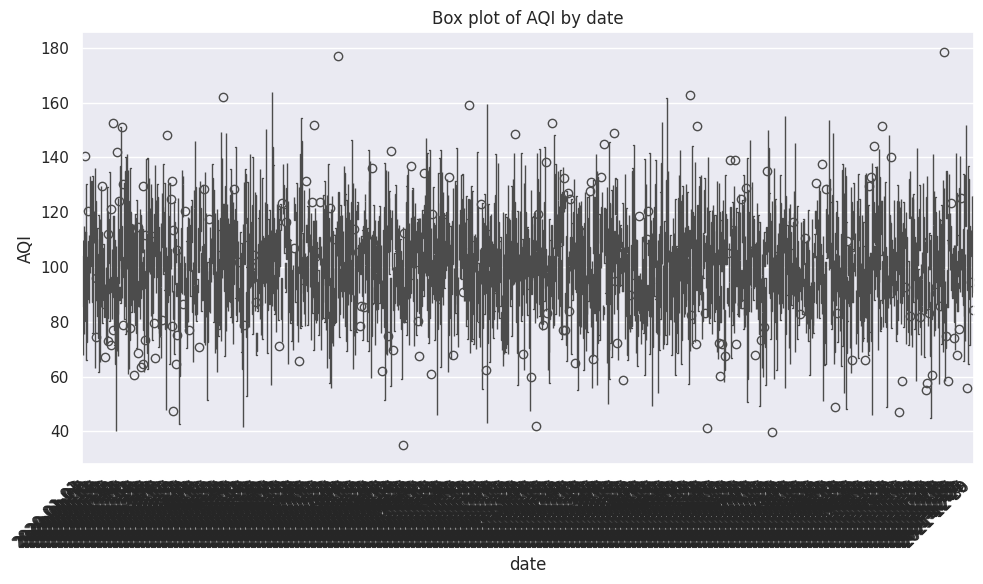

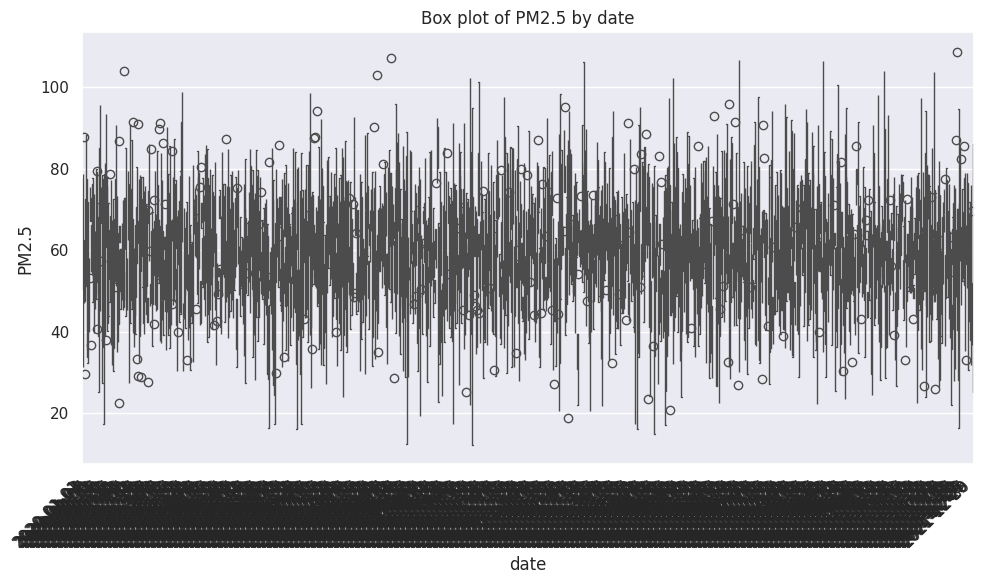

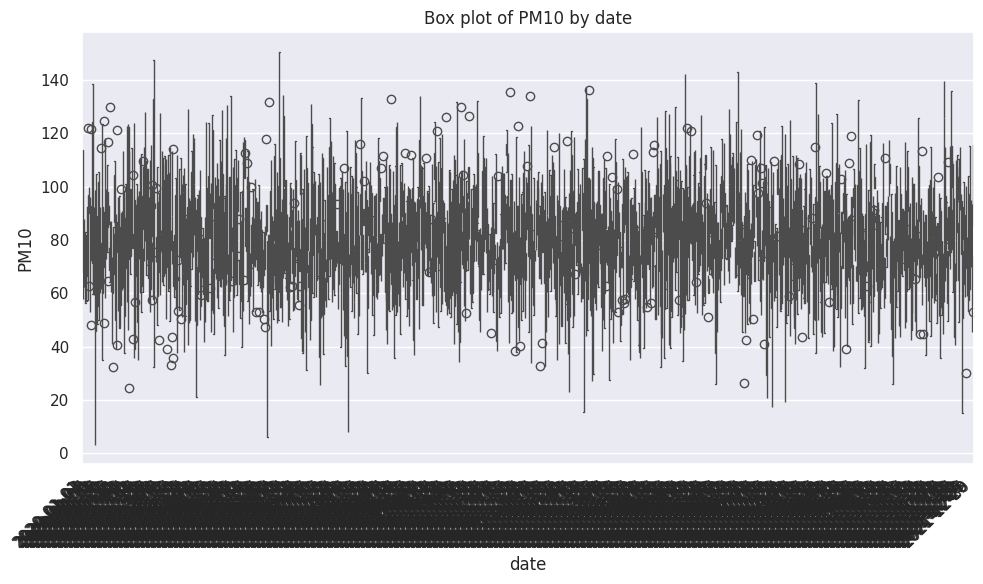

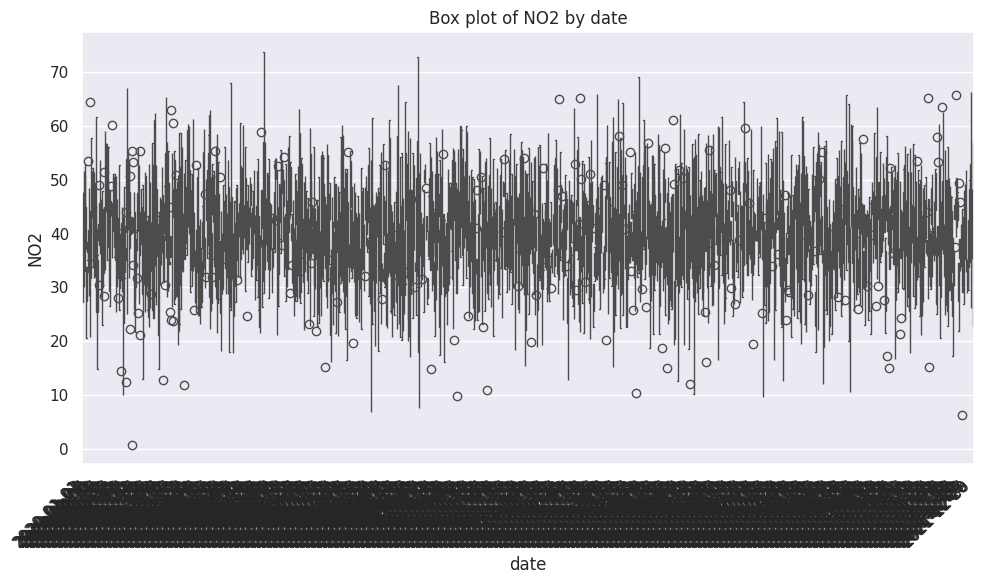

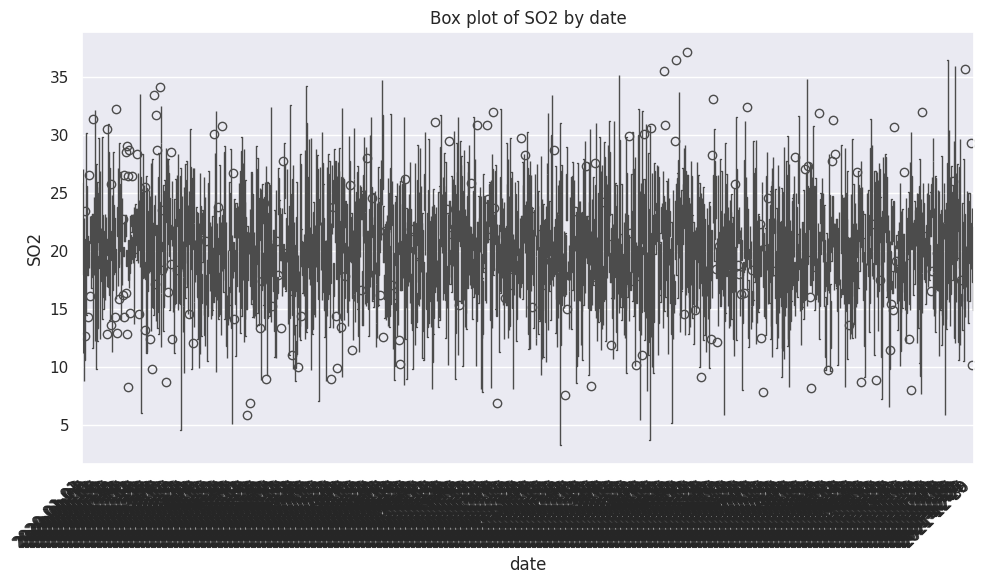

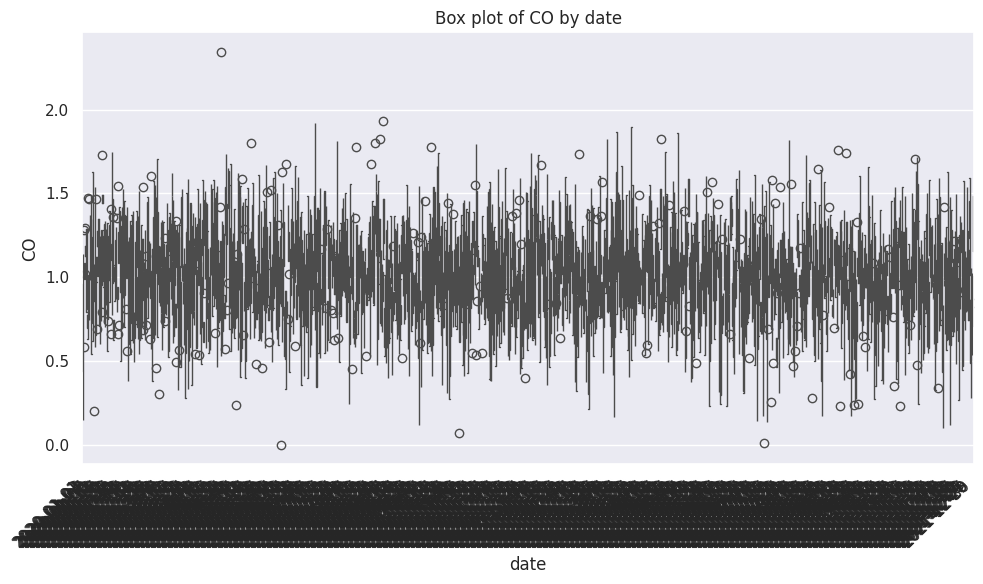

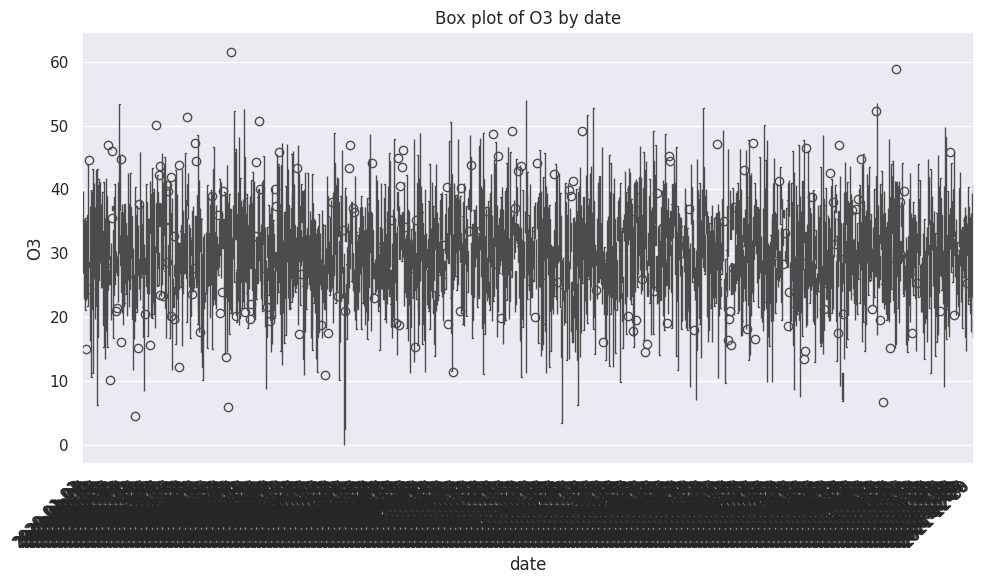

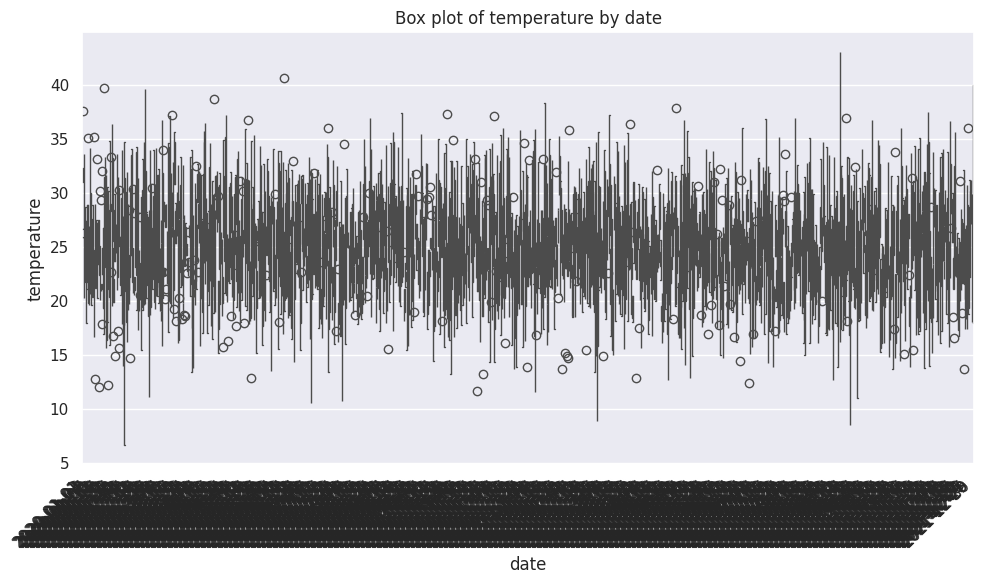

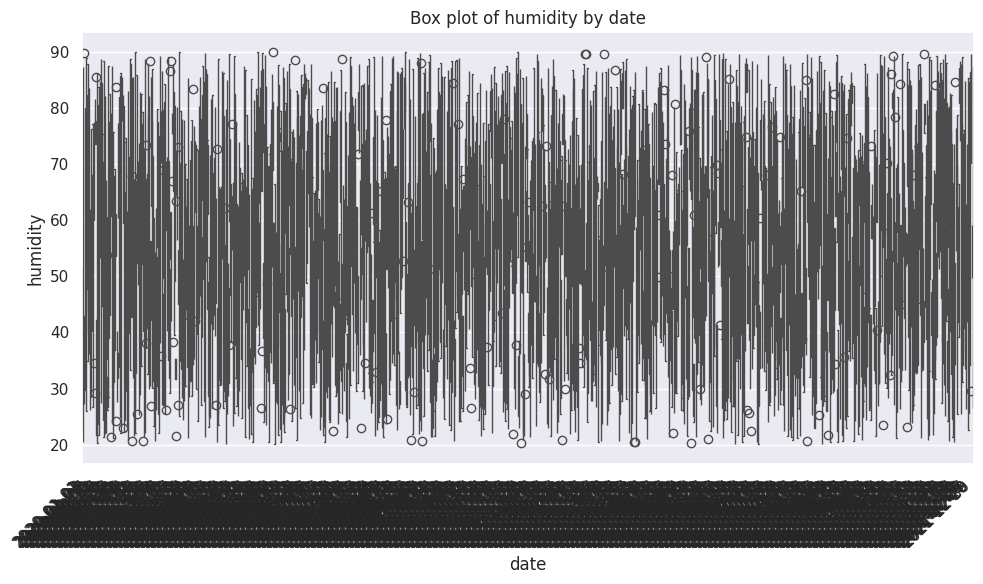

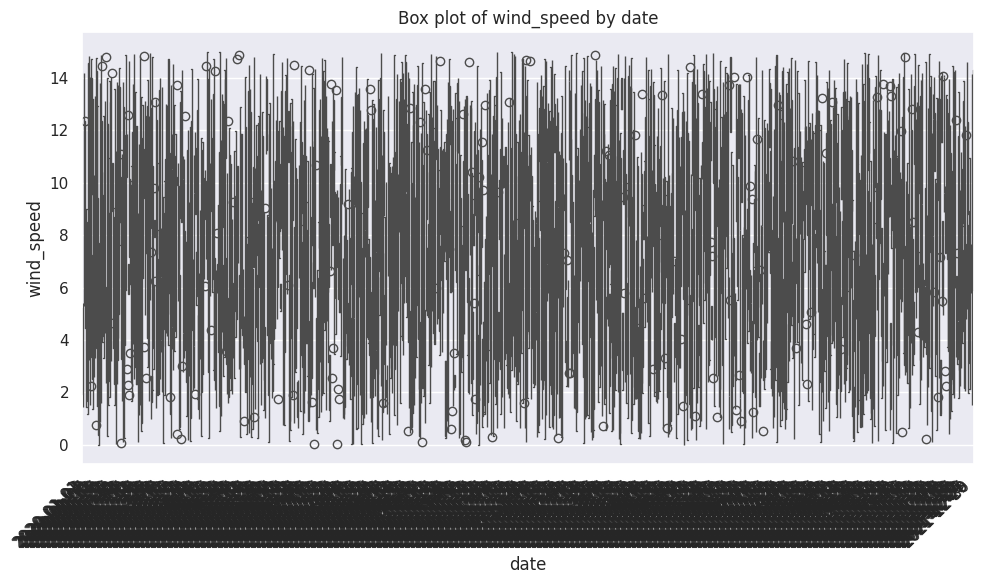

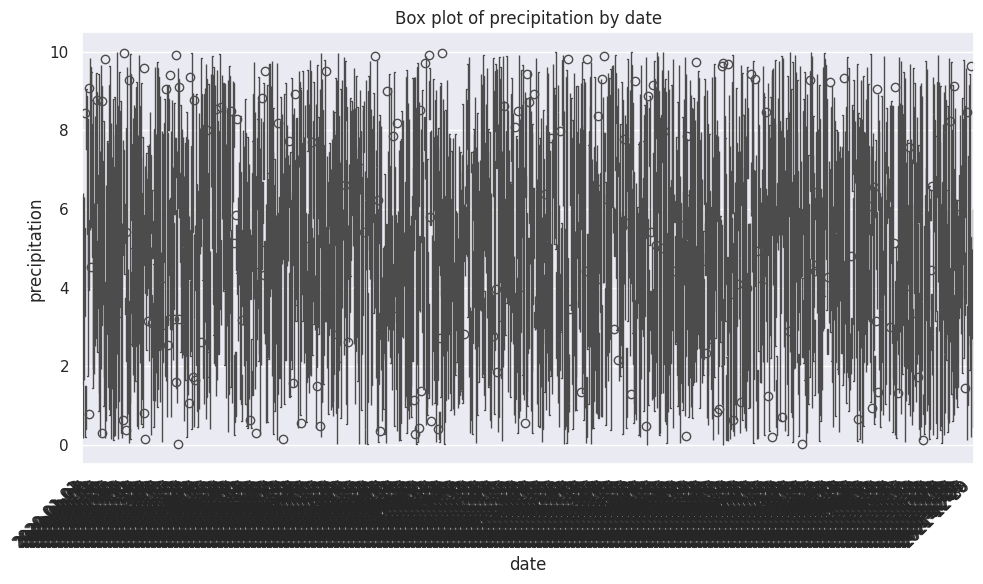

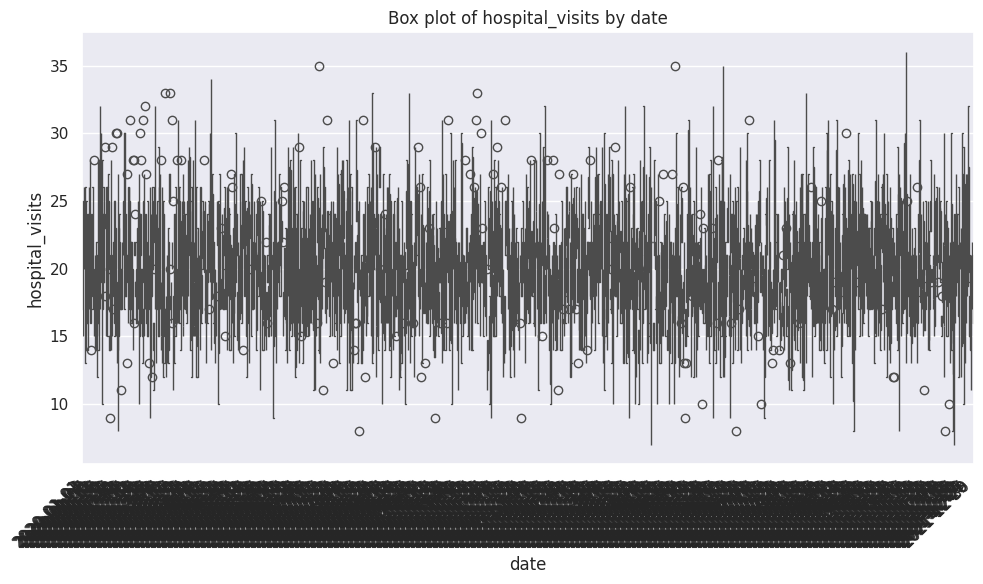

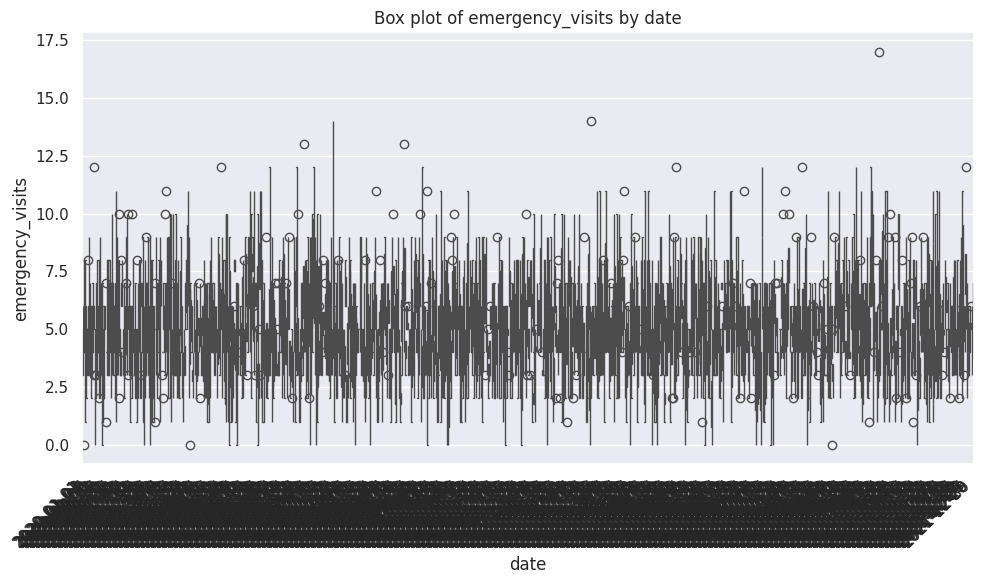

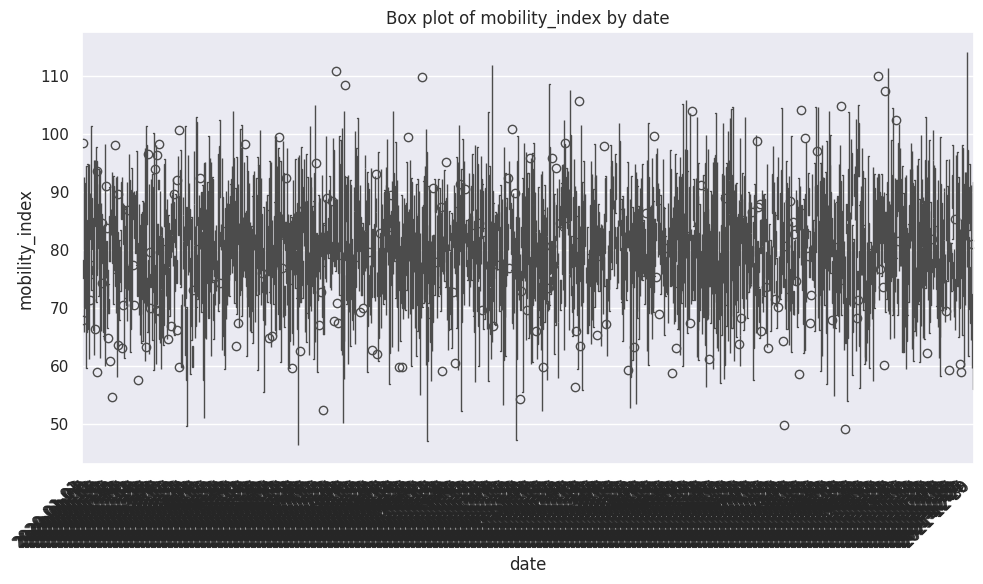

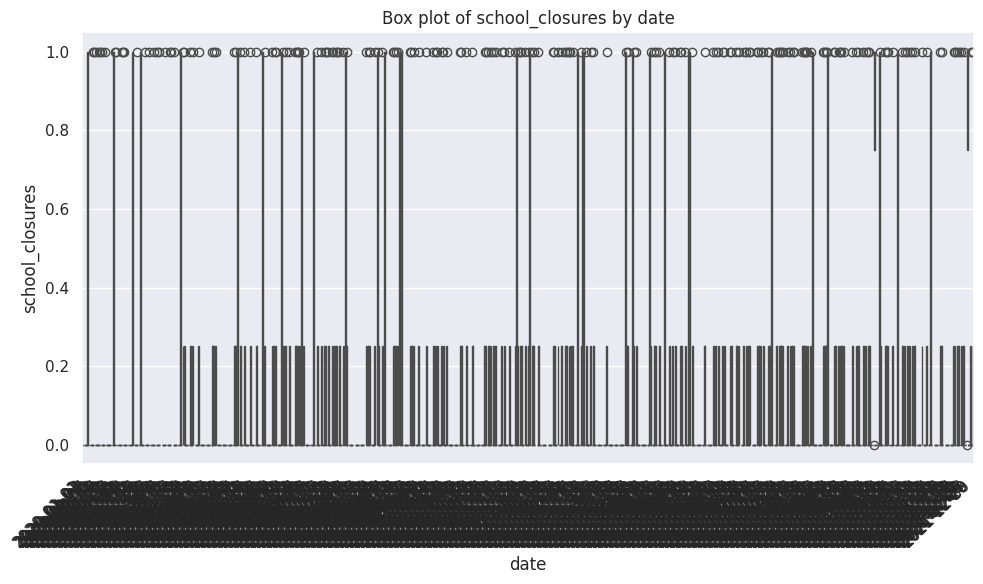

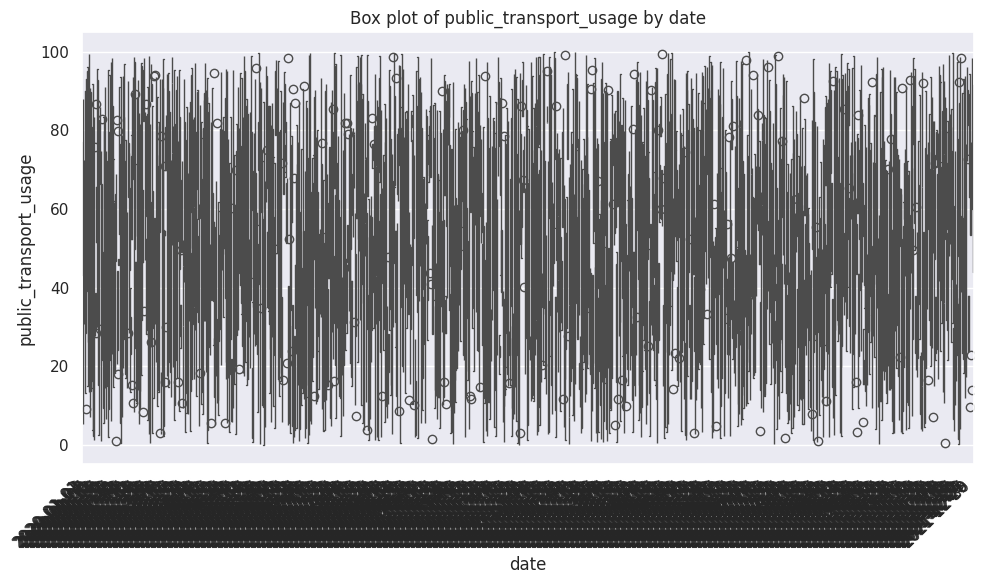

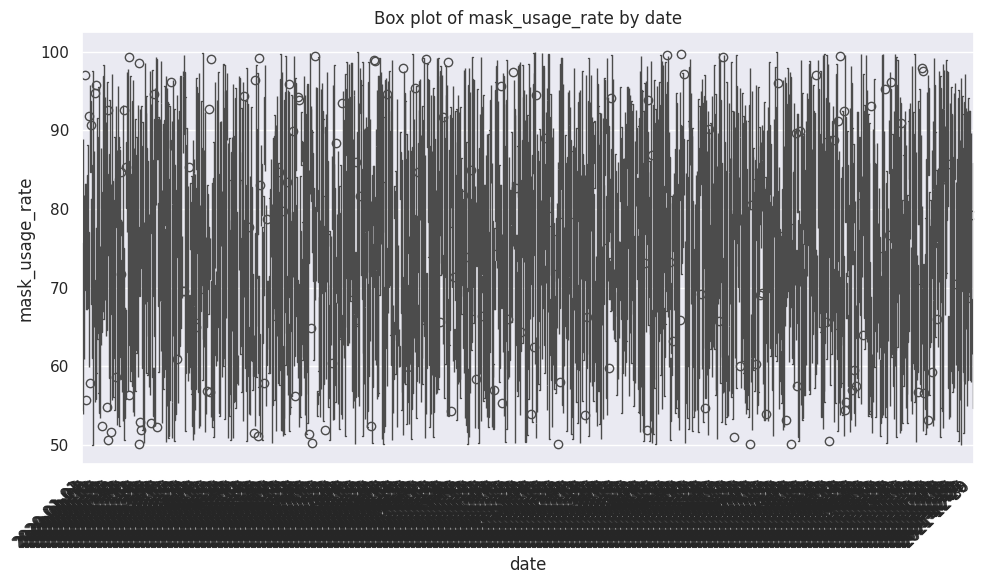

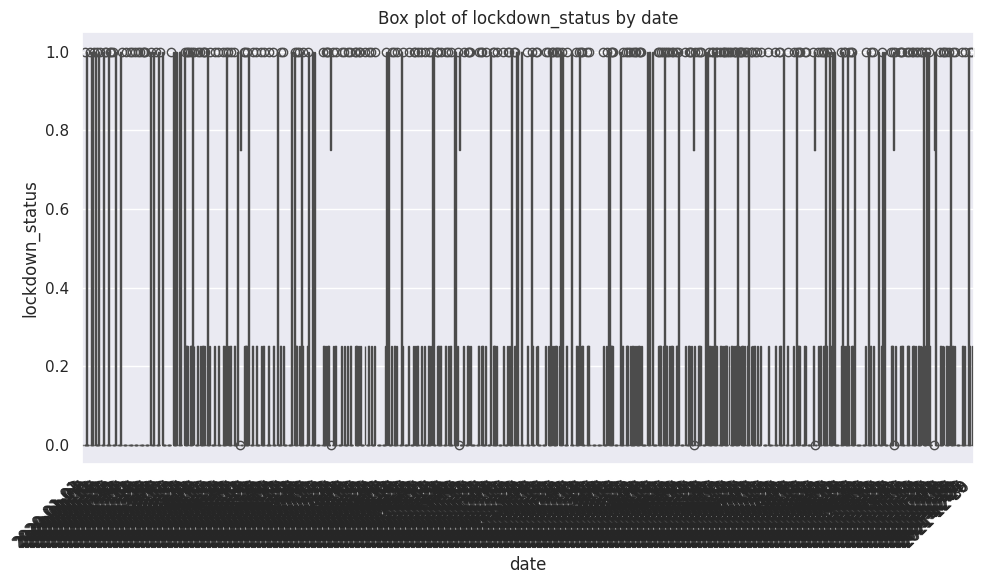

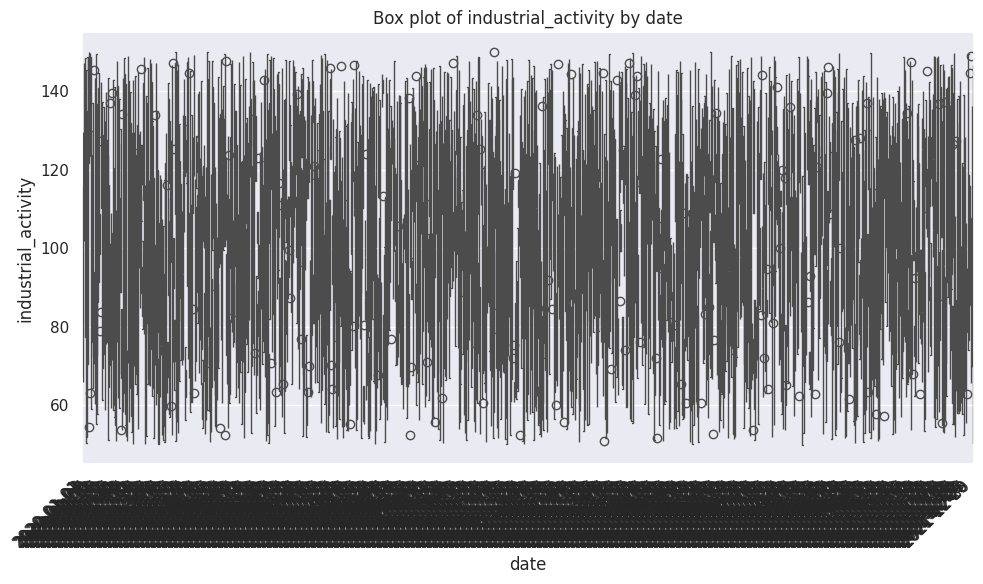

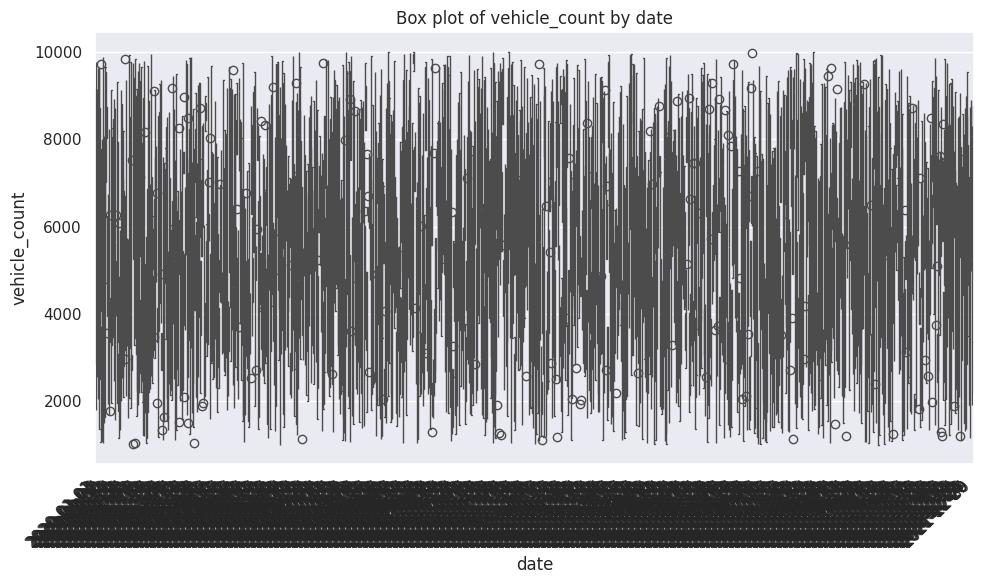

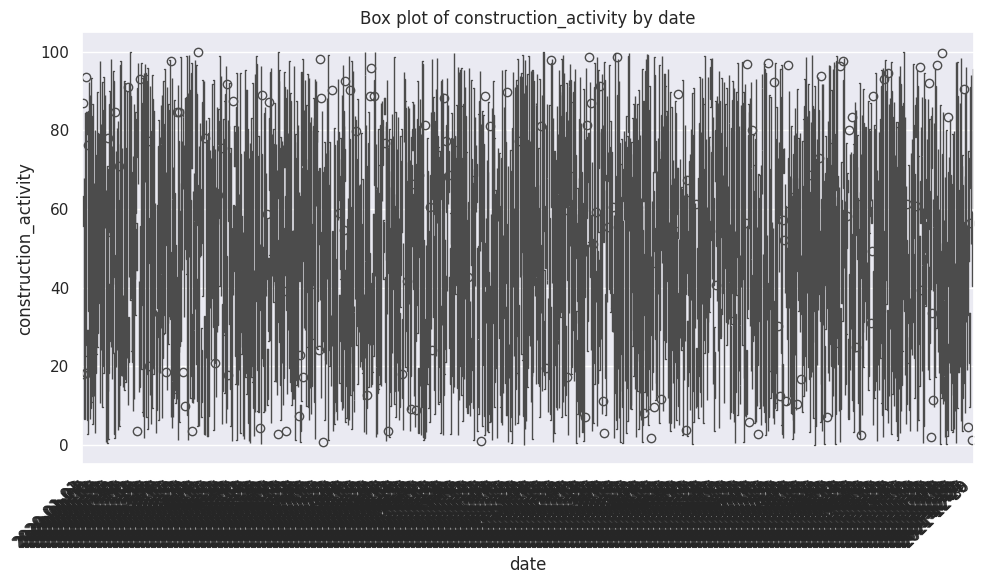

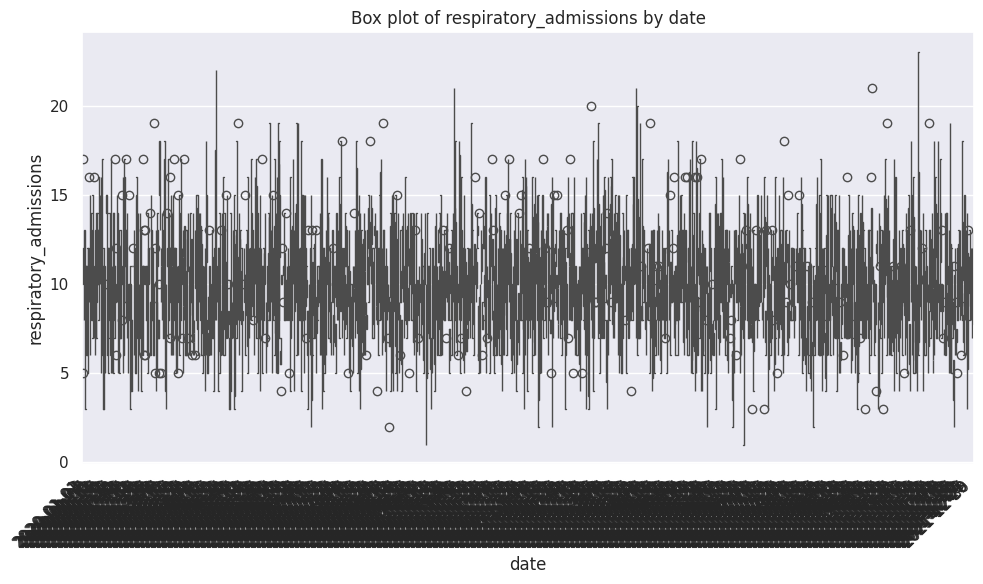

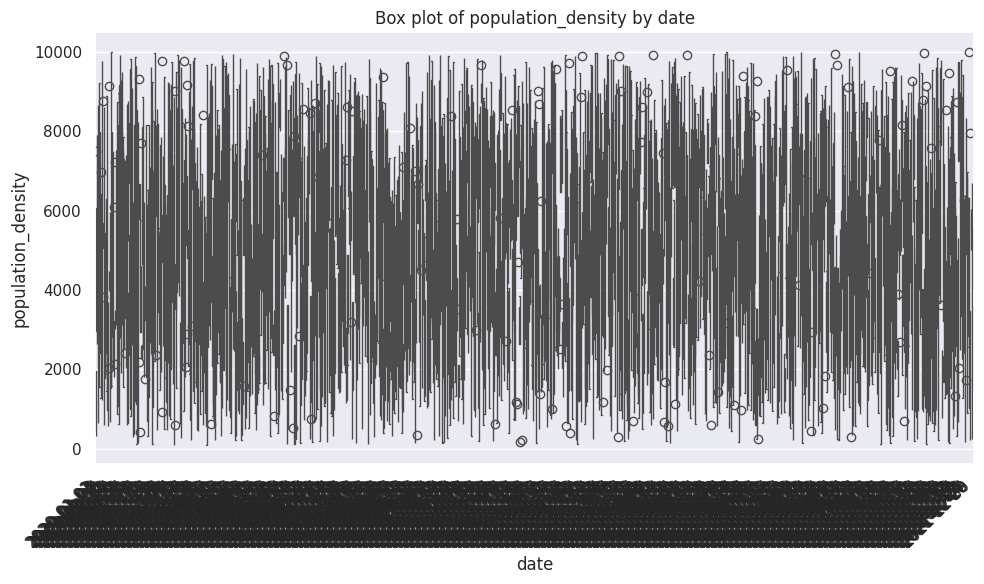

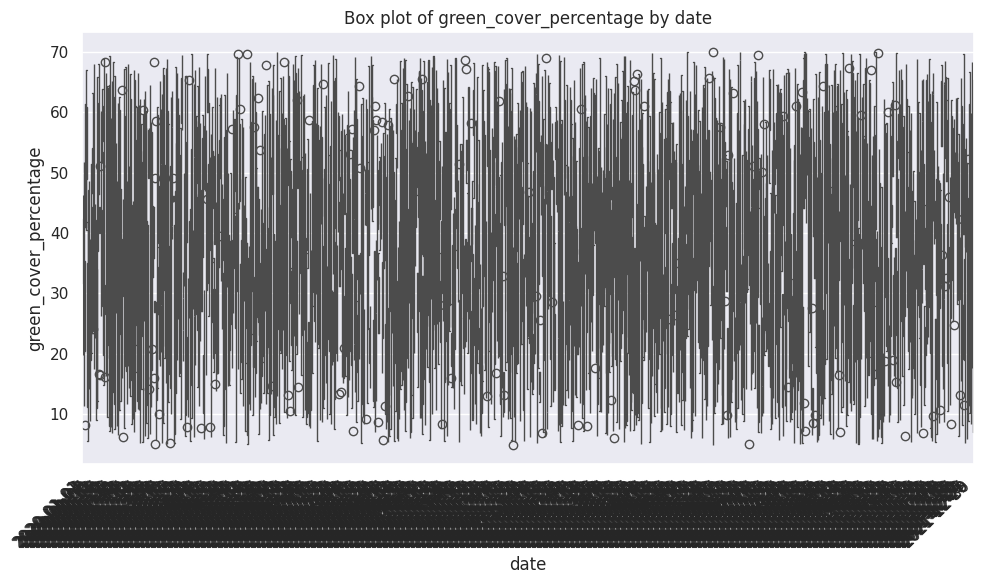

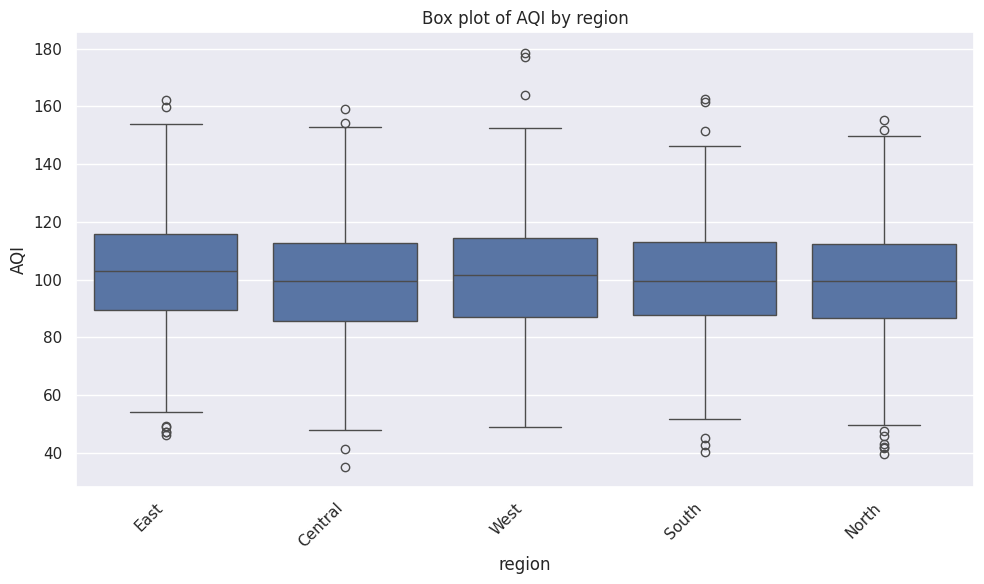

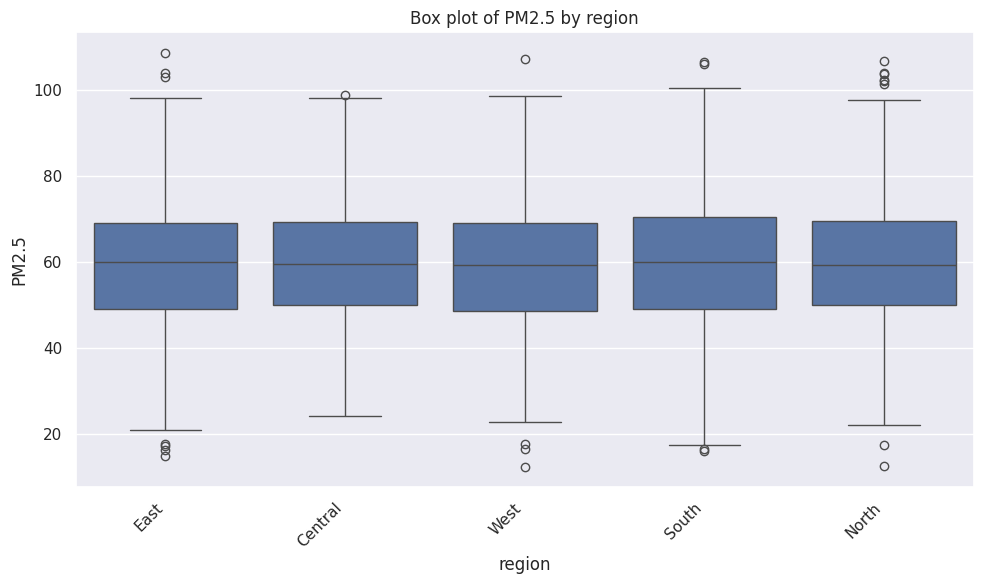

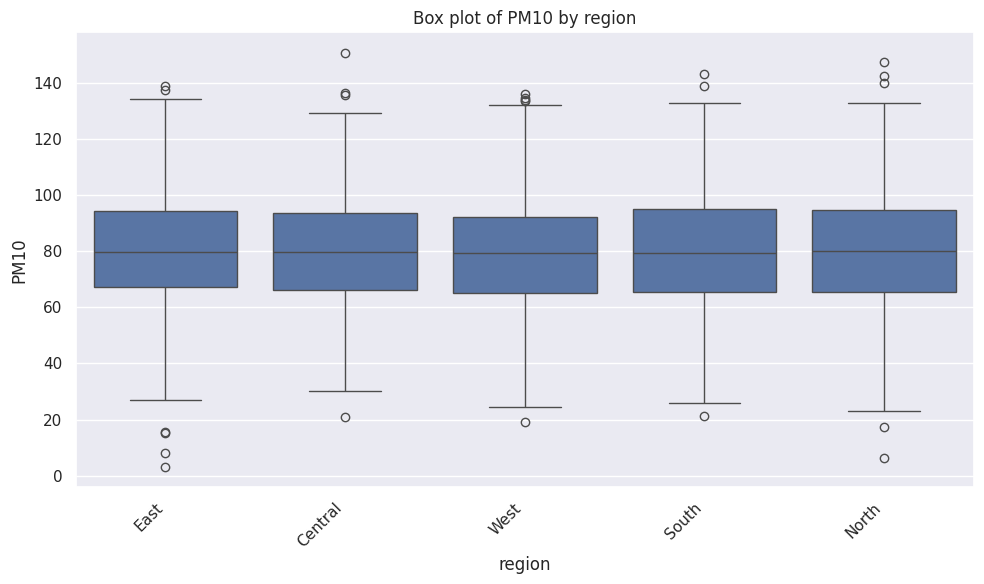

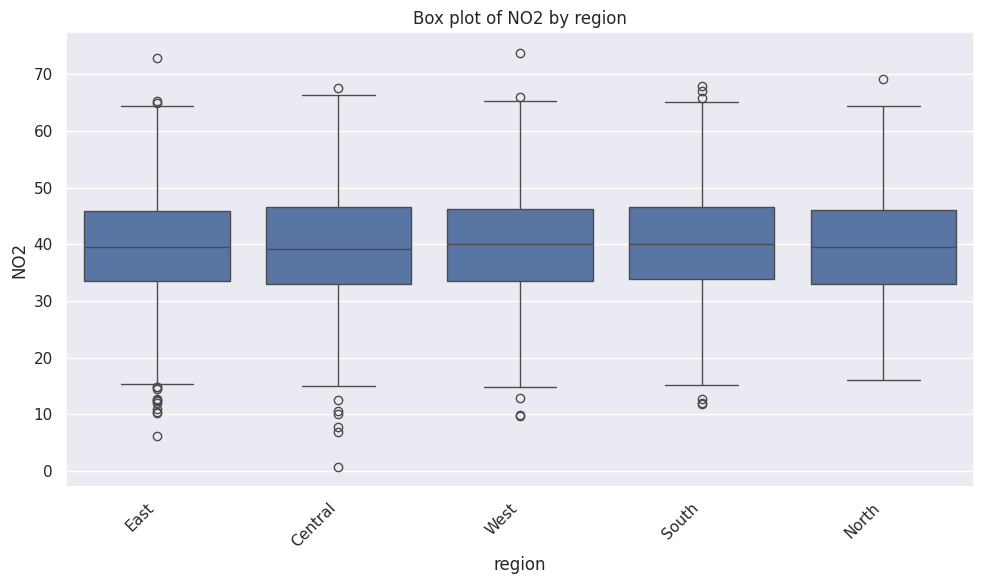

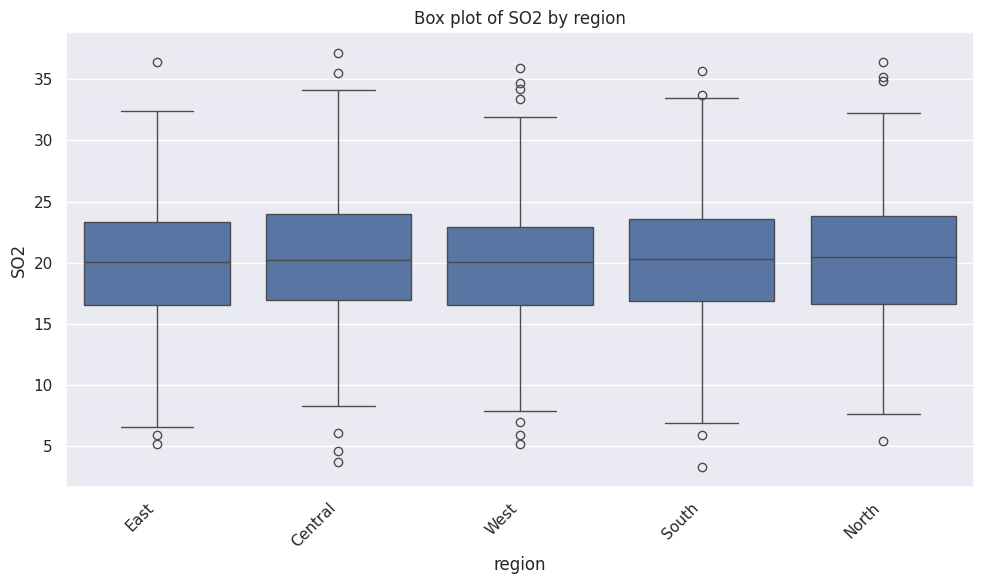

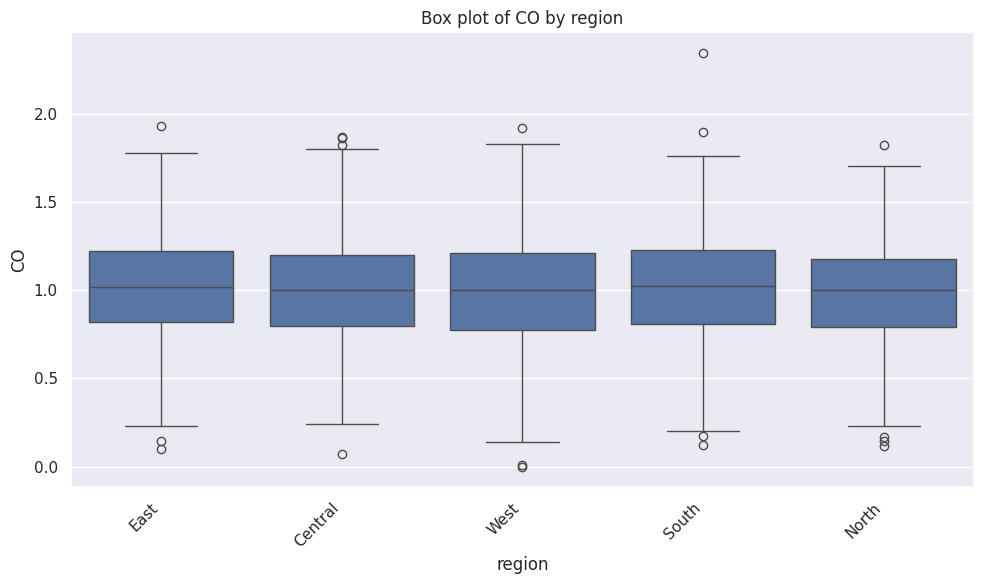

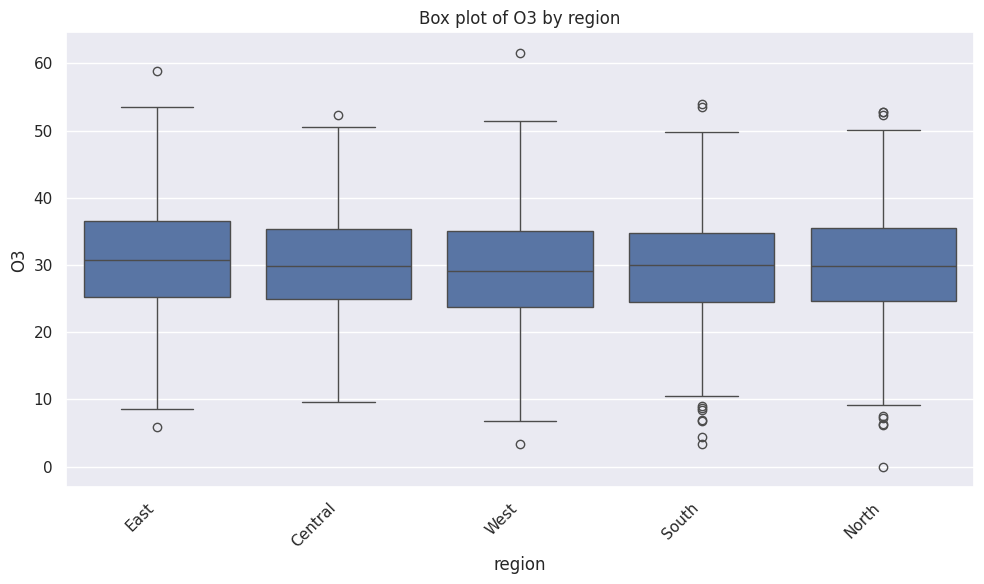

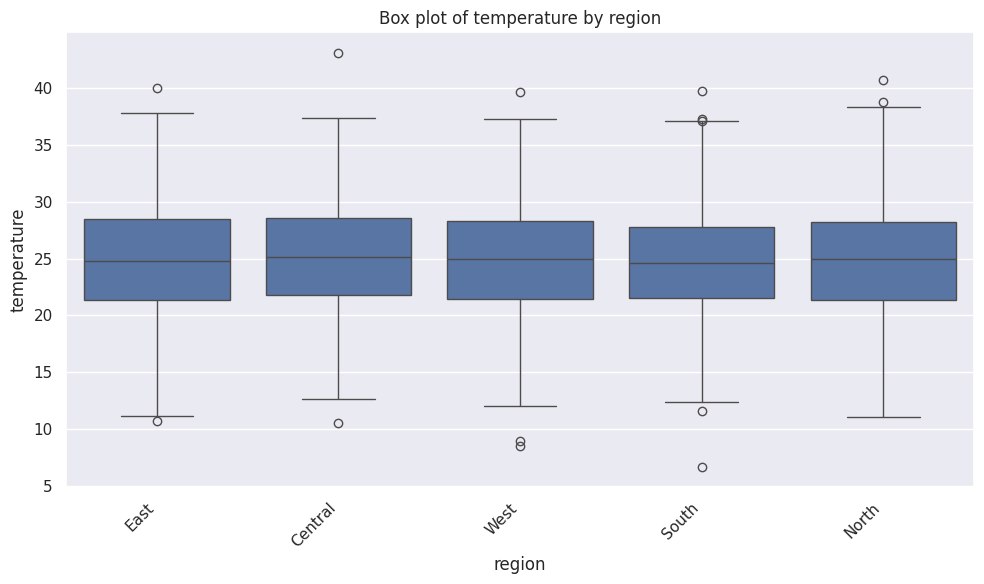

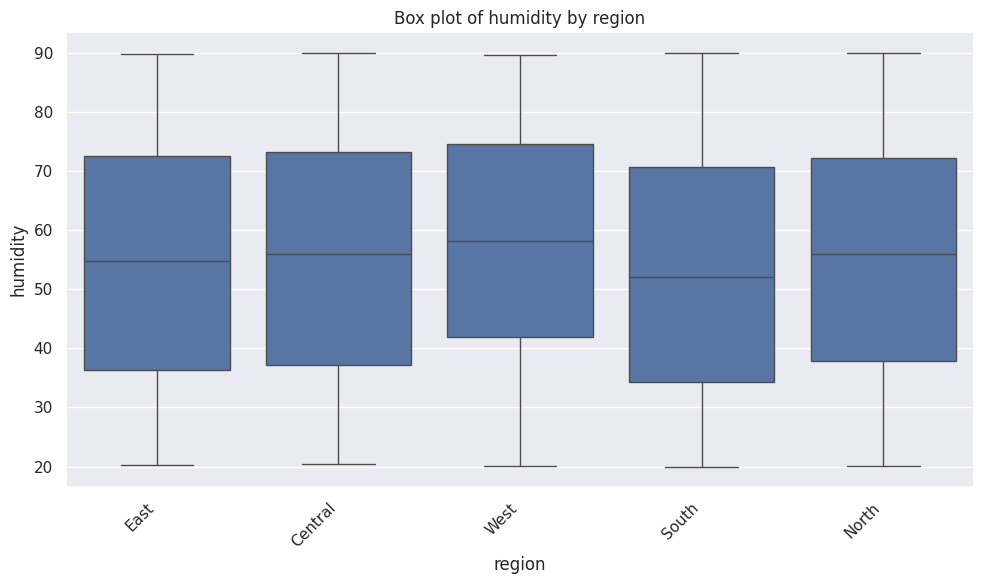

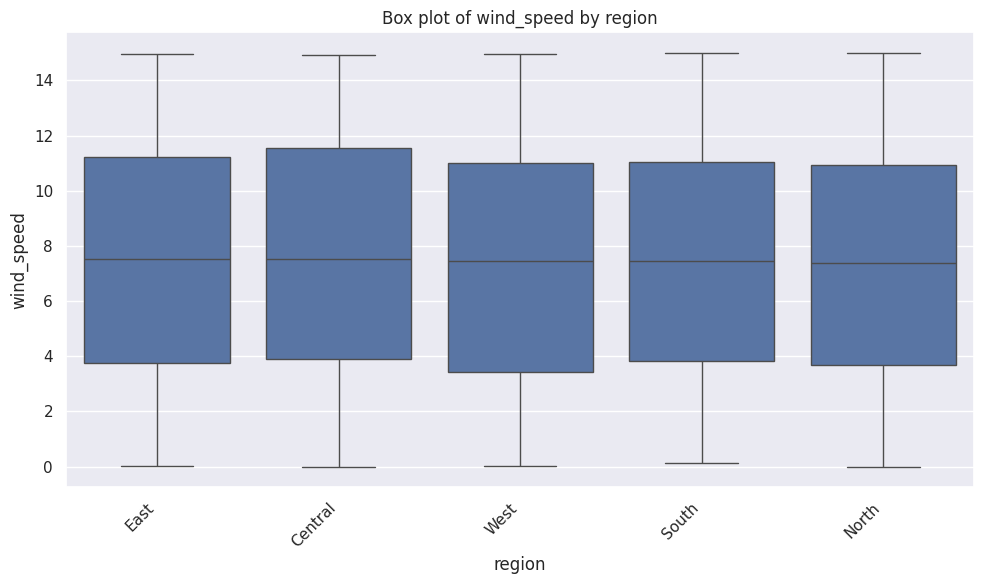

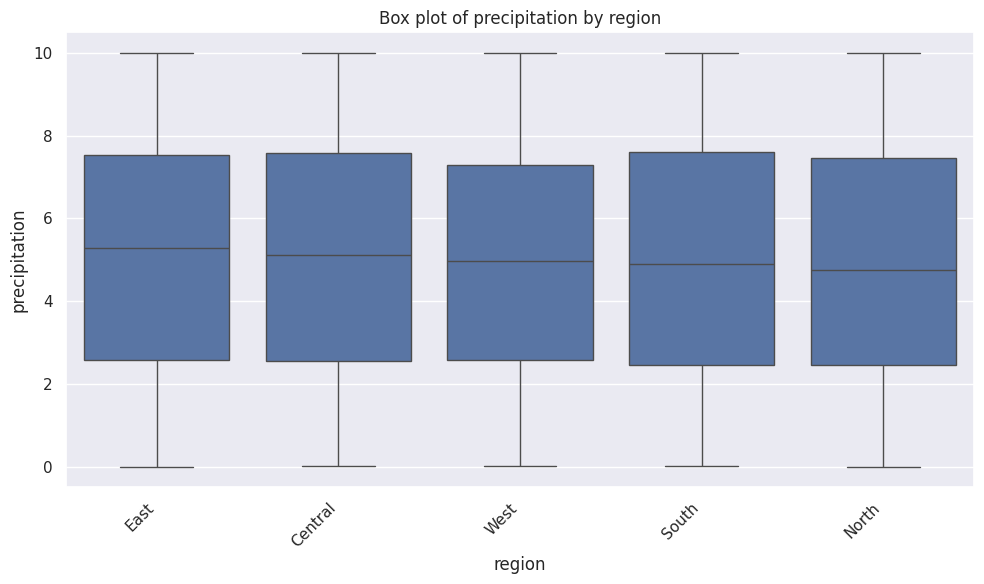

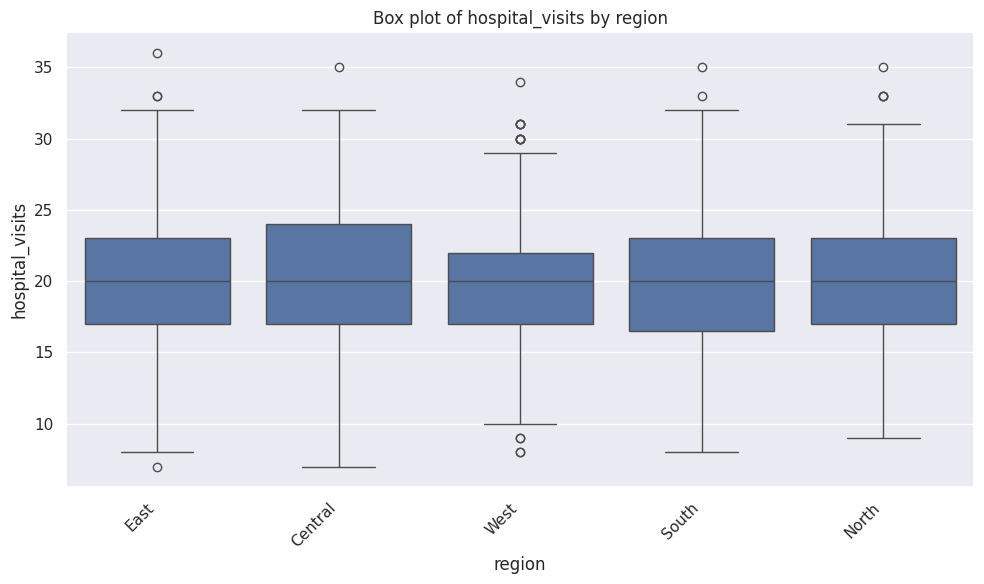

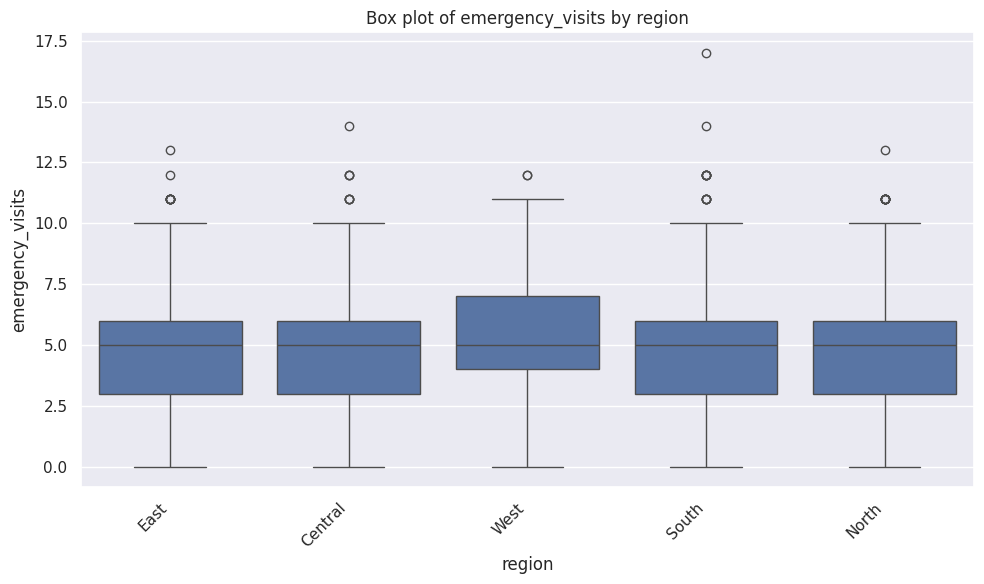

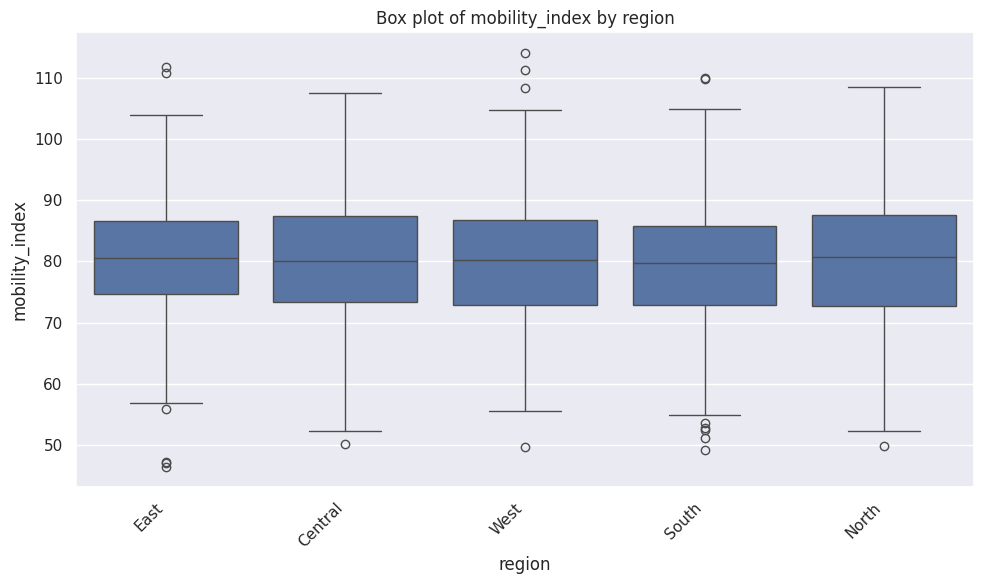

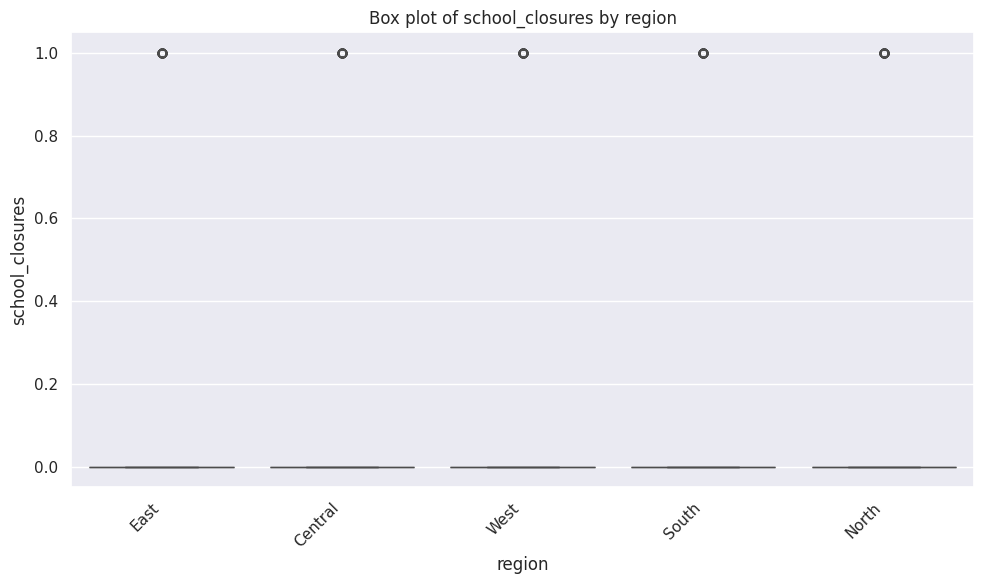

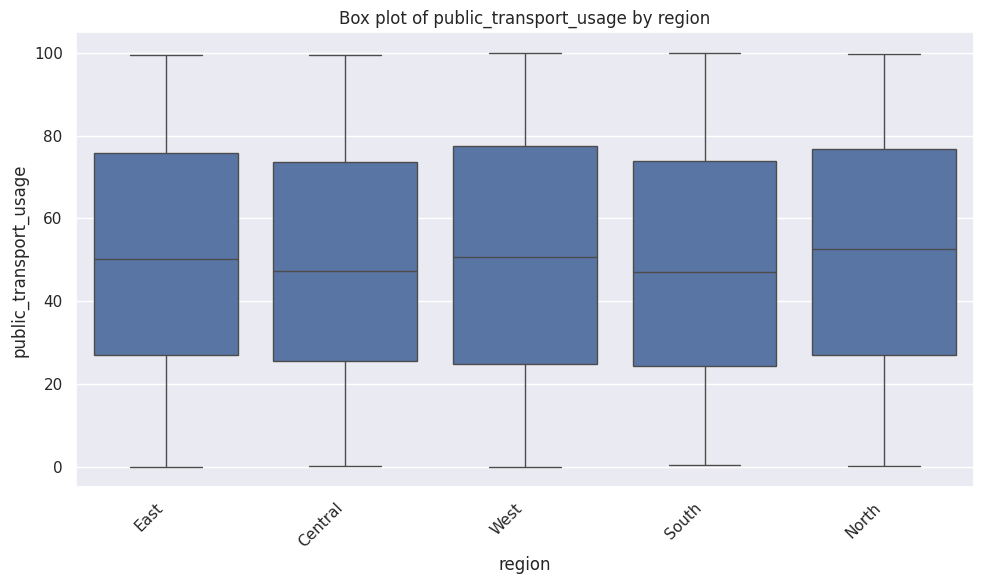

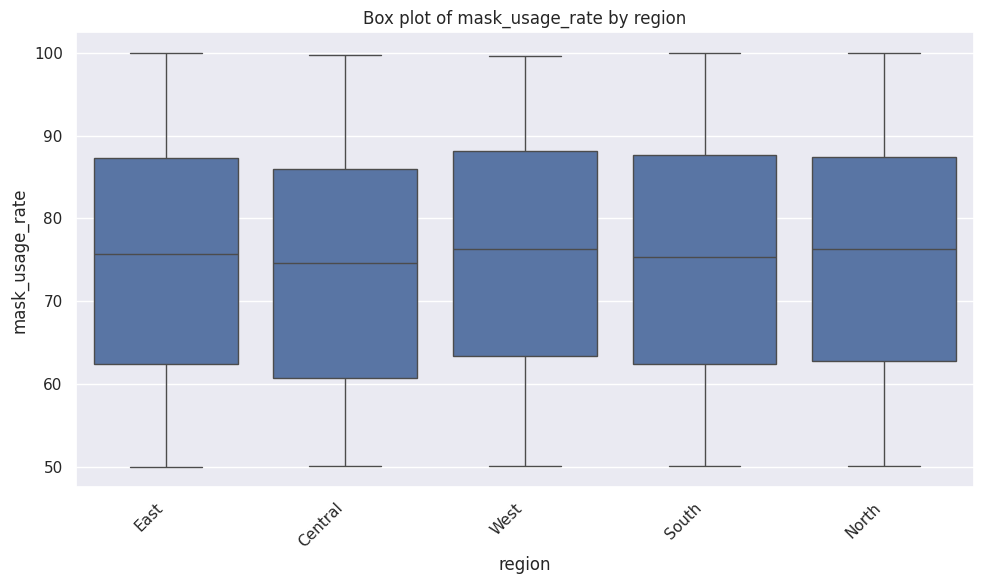

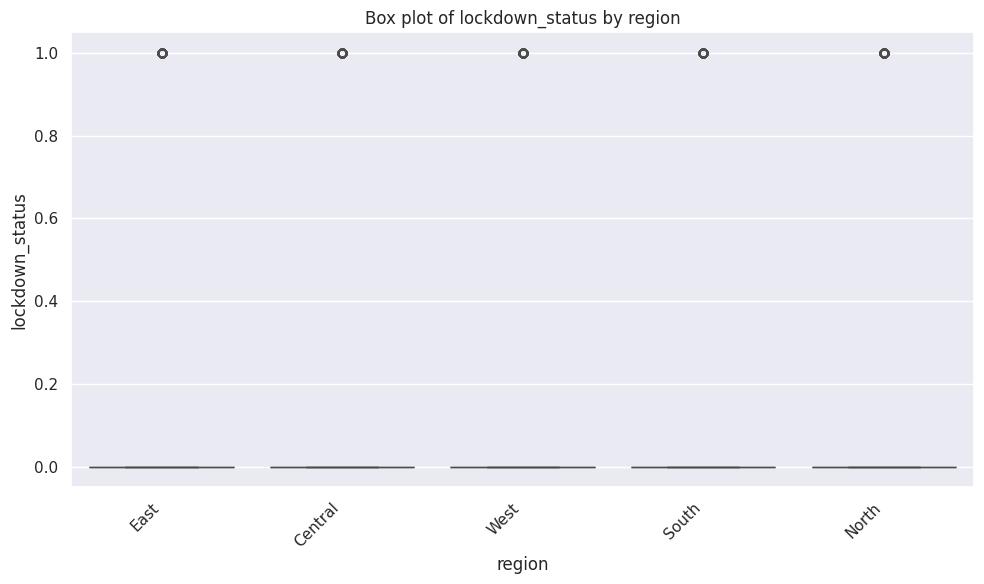

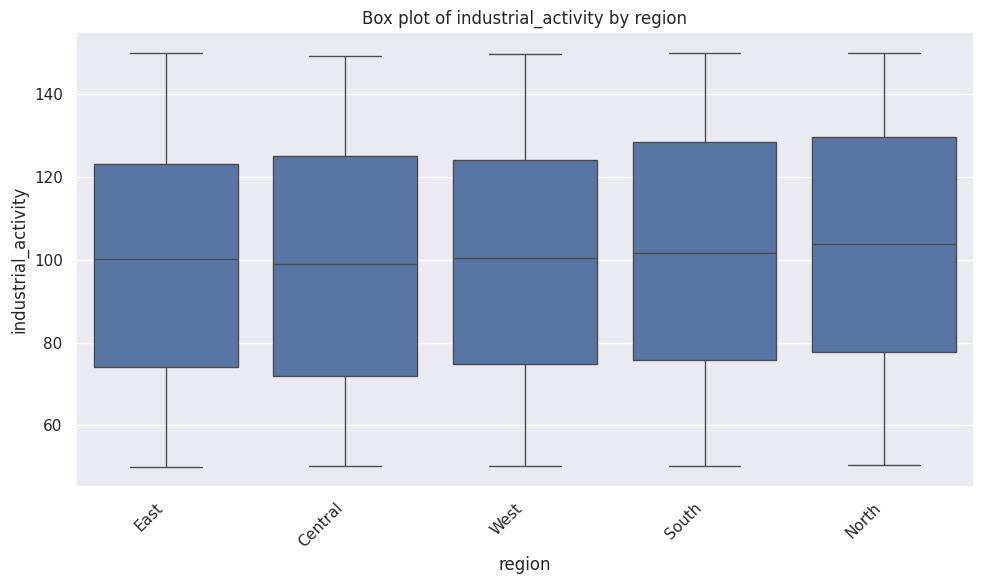

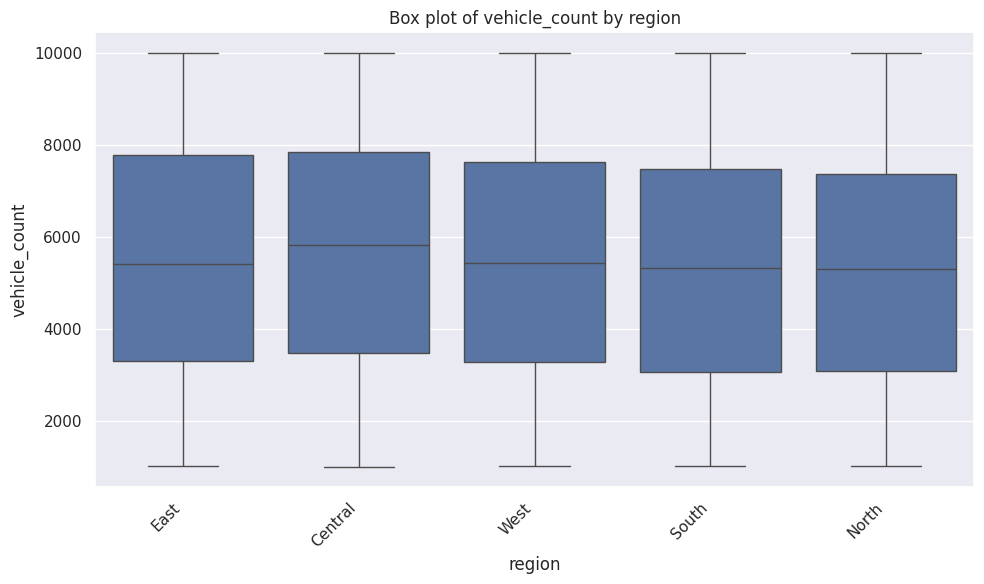

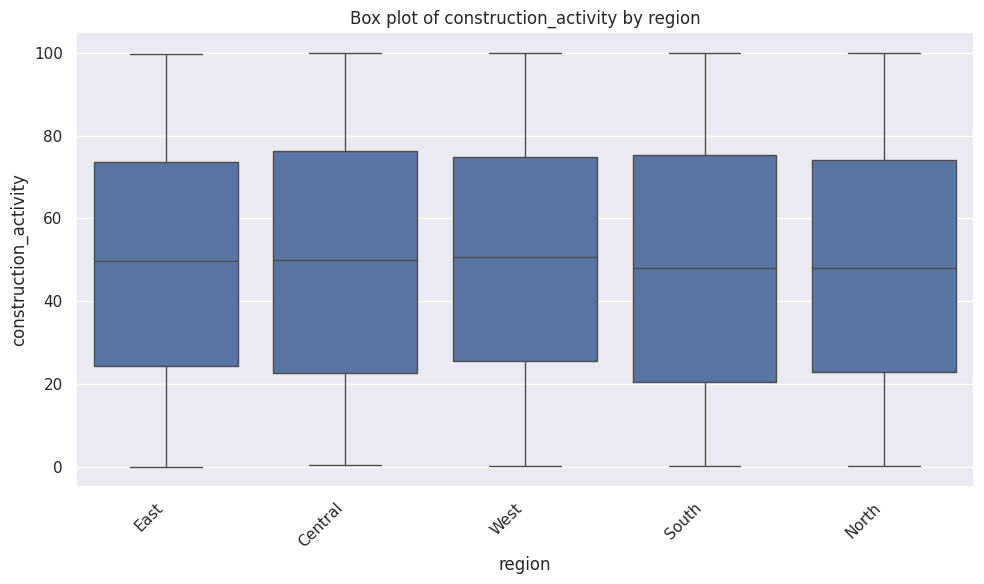

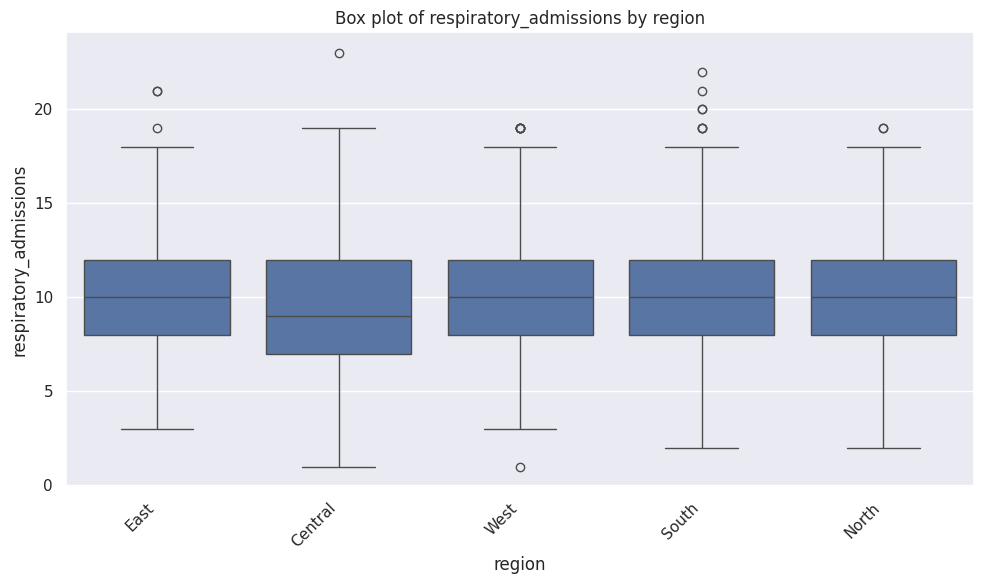

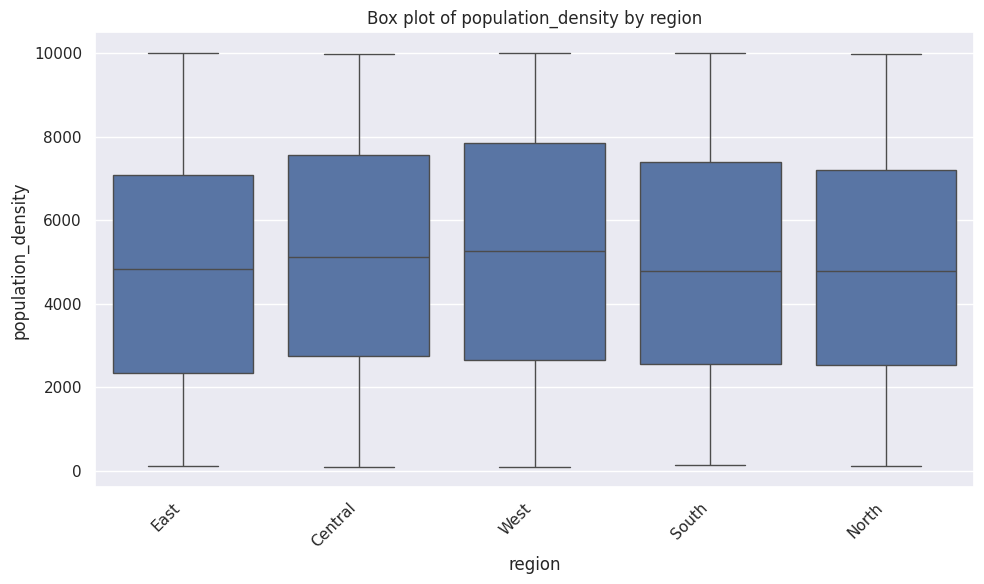

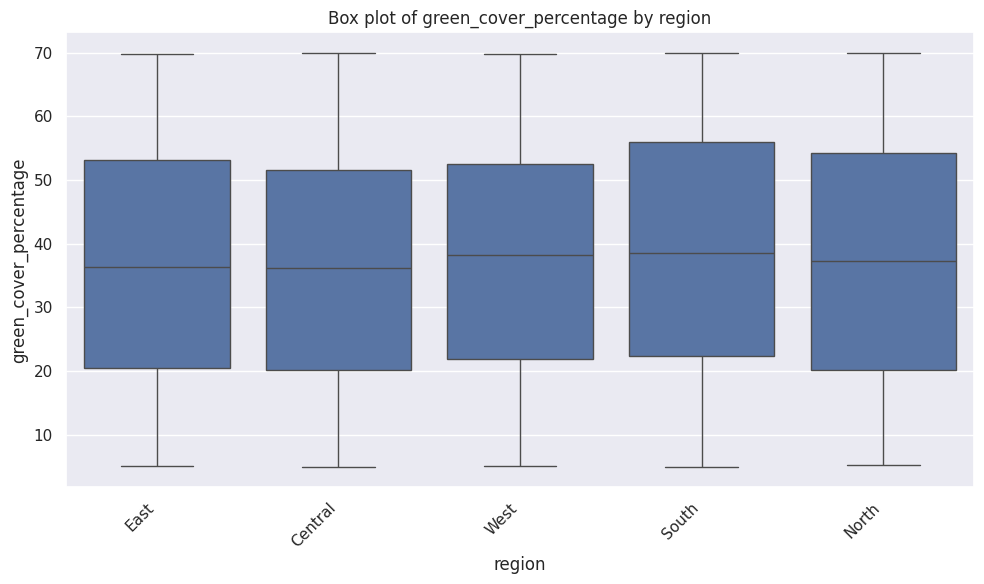

In [23]:
# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

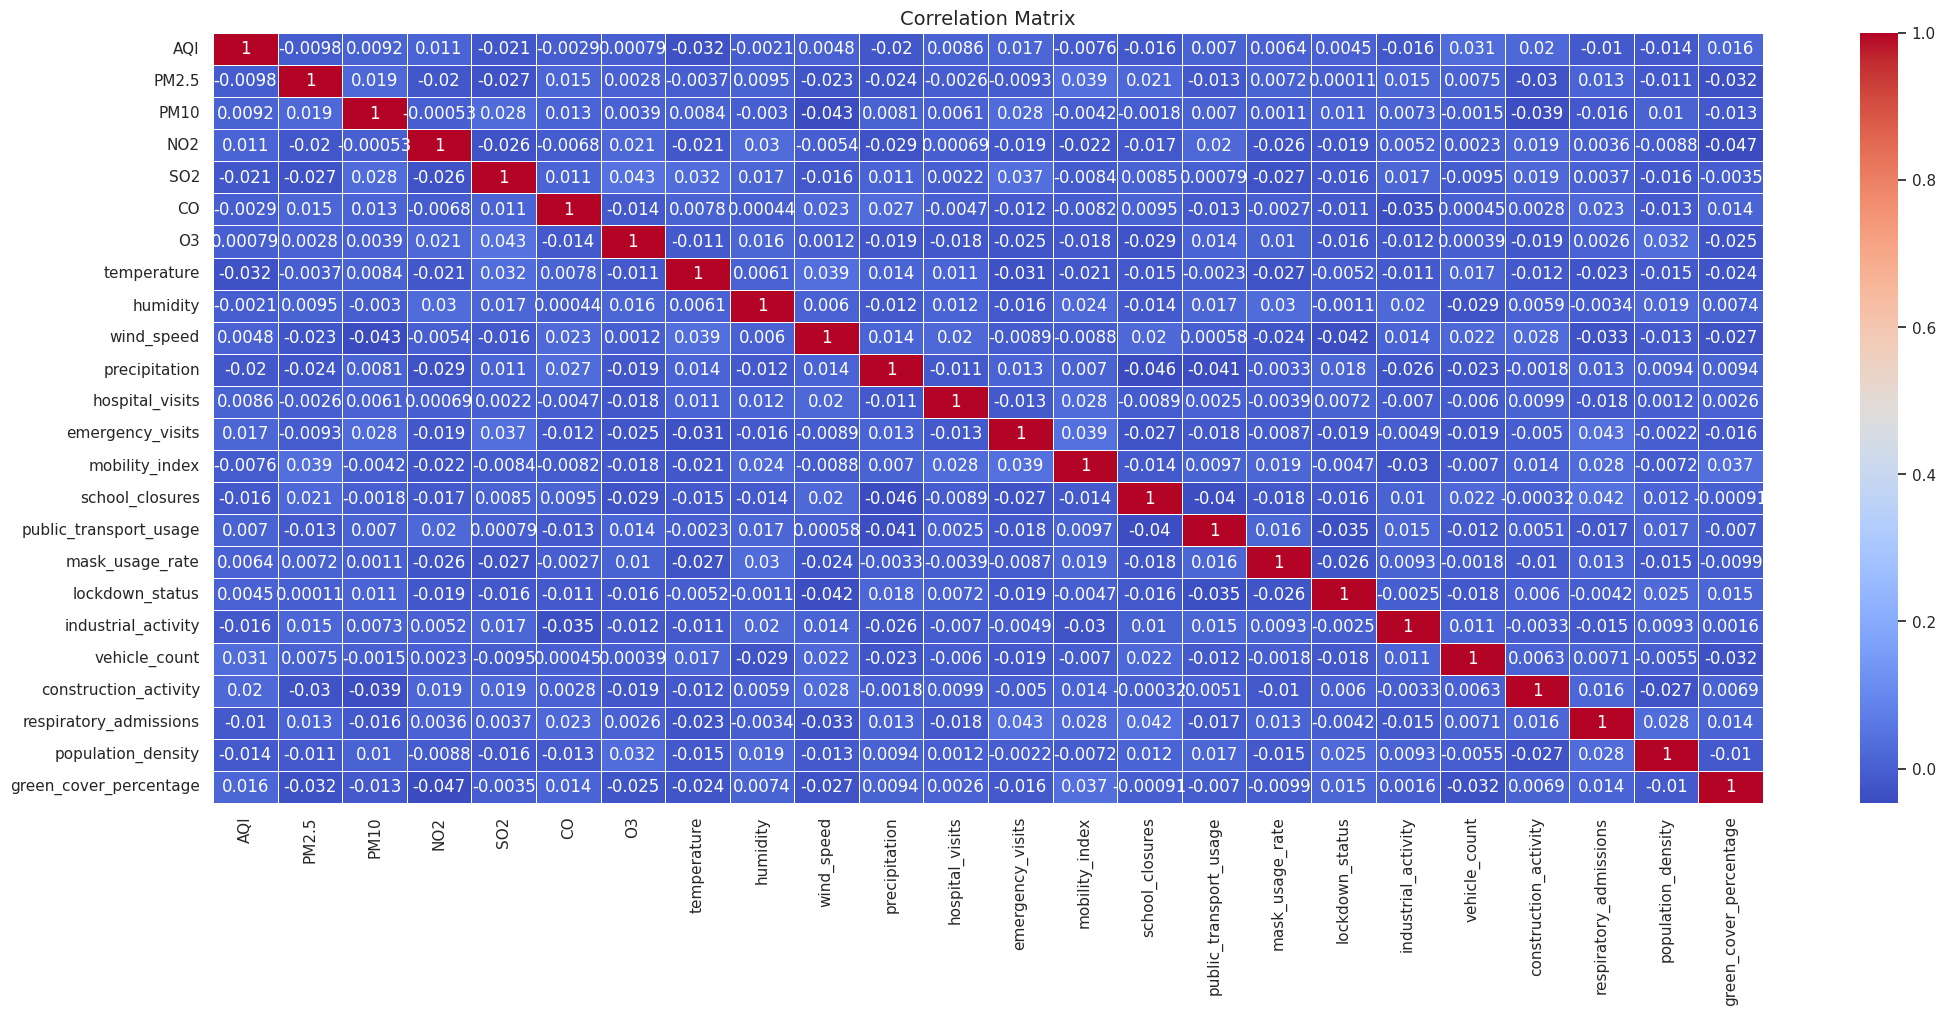

In [22]:
plt.figure(figsize=(25, 10))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you